# 1D Biot Poroelasticity + Coulomb Friction — Radau IIA

Self-contained demonstration of the `solve_nivp` nonsmooth IVP driver
on a 1D saturated poroelastic column whose right boundary is held in
compression against a rigid wall with Coulomb friction. Time
integration uses the Breuling projected two-stage Radau IIA path:
stage cone laws are enforced on cumulative percussions `A @ dPi`,
followed by an endpoint projection on the total percussion.  The
default normal-cone realization below is Fischer–Burmeister.

## Governing equations

On $\Omega = (-D/2,\,D/2)$ the Biot u–p–v system is

$$
\begin{aligned}
\rho_{11}\,\partial_t v + \rho_{12}\,\partial_t r
  &= \partial_x \sigma'(u,v) - \alpha\,\partial_x p,\\[2pt]
\rho_{12}\,\partial_t v + \rho_{22}\,\partial_t r
  &= -\,\partial_x p - b r,\\[2pt]
M^{-1}\,\partial_t p + \alpha\,\partial_x v + \partial_x r &= 0,
\end{aligned}
$$

with effective stress
$\sigma'(u,v) = (K_b + \tfrac{4}{3}G)\,\partial_x u
+ \eta_s(K_b + \tfrac{4}{3}G)\,\partial_x v$
and Biot modulus $M$. Density coefficients $\rho_{11},\rho_{22},\rho_{12}$
come from the standard $(1-\varphi)\rho_s + \varphi\rho_f$ partition
with tortuosity correction.

## Boundary condition — frictional contact at $x=D/2$

The right wall is subject to a compressive prestress
$\sigma_{11}^{\text{eff}} < 0$ and Coulomb friction with a
slip-weakening coefficient
$\mu(s) = \mu_{\text{res}} - \Delta\mu\,e^{-s/D_c}$. The tangential
reaction is confined to the cone
$\mathcal{K}_\mu = \{(r_N, r_T) : |r_T| \le \mu(s)\,r_N\}$,
and the slip rate is recovered through the augmented ODE
$\dot s = |v_2(L)|$.

A slip event is expected whenever the effective stiffness drop
$\Delta\mu\,\sigma_{11}^{\text{eff}} / D_c$ exceeds the elastic
restoring stiffness $G/D$, giving the closed-form asymptotic

$$
s_\infty \;=\; -\,\frac{\Delta\mu \, \sigma_{11}^{\text{eff}}\,D}{G},
$$

which we use as the analytical reference.


## Imports and package setup

Pull in `scikit-fem` for the spatial discretisation, `solve_nivp` for
the integrator + projection stack, and the usual numerical scaffolding.


In [1]:
import numpy as np

from skfem import Basis, ElementVector, ElementComposite, FacetBasis
from skfem.assembly import asm, BilinearForm, LinearForm
from skfem.helpers import grad, sym_grad, div, dot, ddot, trace, eye
from skfem import MeshQuad1, ElementQuad0, ElementQuad1, ElementQuad2, ElementQuadRT0, ElementTriP1, MeshTri
from skfem import ElementLineP2, ElementLineP1, ElementLineP0, MeshLine
from skfem.visuals.matplotlib import draw

import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix, lil_matrix
from scipy.integrate import solve_ivp
from scipy.sparse.linalg import splu, spsolve

import ipywidgets as widgets
import time

import solve_nivp
from solve_nivp.contact import build_impulse_contact

## Physical parameters

All quantities are expressed in a length-scaled unit system
(`L = 1e-6 m`). The drained bulk modulus $K_b$, shear modulus $G$,
Biot coefficients $\alpha, M$, and undrained wave speeds are derived
from the fluid/solid base properties so the time step can be compared
to a characteristic $D / v_w$.


In [104]:
L = 1e-3#.00001 #[m]

ρf = 1000 * L**3
ρs = 2500 * L**3

Kf = 2.2e9 * L**1
Ks = 80e9 * L**1
nu = .15
φ = .2
α = 0.6

turt = 1. # 1 straight pores, should be larger than 1

k_vv = 1e18*L**3
k_vu = 1e18*L**3
k_r = 1e21*L**3
ηs = 9e-1

k = 1e-14 * L**-2
μf = 1e-3 * L**1

Kb = Ks*(1-α)
G = 3/2*Kb*(1-2*nu)/(1+nu)
M = ((α-φ)/Ks + φ/Kf)**-1
# ρ11 = (1 - φ) * ρs + φ * ρf
# ρ12 = ρf
# ρ22 = ρs / φ + ρf / φ**2


ρ11 = (1 - φ) * ρs + (turt - 1) * φ * ρf
ρ22 = turt * φ * ρf
ρ12 = -(turt - 1) * φ * ρf # print(ρ11,ρ22,ρ12)
Δ = ρ11*ρ22 - ρ12**2
mu = G
lam = Kb - 2*G/3
b = (k / μf)**-1

# robin_left = (k_vv*0, 0, k_vu*0, 0, k_r)
# robin_left = (k_vv, k_vv, k_vu, k_vu, k_r)
# robin_right = (0, 0, 0, 0, k_r)
robin_left = (0, k_vv, 1.5e8*L**3, k_vu, k_r)
robin_right = (0, 0, 0, 0, k_r)

bc_dofs = {
    # 'u1': {'left': 0.},
    # # 'v1': {'left': 0.},
    'u2': {'left': 0.},
    # # 'v2': {'left': 0.},
    # 'u1': {'left': 0.,'right': 0.},
    # # 'v1': {'left': 0.,'right': 0.},
    # 'p': {'left': 0.,'right': 0.},
    # 'p': {'left': 0.,'right': 0.},

}


Dc=.10 /1000/L #mm
Dmu=-.1
mu_res=.5
s11_eff_0 = 4*1e6 * L**1
friction_sides = ["right"]
# friction_sides = []

# Domain
D = 1000. #[m]

Ku = Kb + α**2*M
rho_b = (1-φ)*ρs + φ*ρf
vw = np.sqrt((Ku + 4/3*mu)/rho_b)
print("Δ:",Δ)
print("α:",α)
print("Kb:", Kb*1e-9*L**-1)
print("G:", G*1e-9*L**-1)
print("M/Kb:",M/Kb)
Cm = np.array([[Kb + 4/3*G, α*M],[α*M, M]])
Rm = np.array([[ρ11, ρ12],[ρ12, ρ22]])
tmp = np.linalg.solve(Rm, Cm)  # = Rho^{-1} C
c2, vecs = np.linalg.eig(tmp)
vw1, vw2 = np.sqrt(c2)

print("undrained wave velocity", vw * L**1)
print("wave velocities", vw1 * L**1, vw2 * L**1)
chy = k / μf / M**-1
print("tch_mech:", (D/2)/ vw1 / L, "[s]", (D/2)/ vw2 / L, "[s]")
print("tch_diff:", (D/L/2)**2/chy, "[s]")
# ── 1-DOF spring-slider: analytical slip with viscous damping ──
L_bar = D / L
k_eff = G / L_bar                        # elastic stiffness at fault
m_eff = ρ11 * L_bar / 2                  # fundamental-mode effective mass
ω0 = np.sqrt(k_eff / m_eff)
ζ  = ηs * k_eff / (2 * np.sqrt(k_eff * m_eff))

EQslip = k_eff < (-Dmu * s11_eff_0 / Dc)
expd_slip_static = -Dmu * s11_eff_0 / G * L_bar

if EQslip and ζ < 1:
    overshoot = np.exp(-np.pi * ζ / np.sqrt(1 - ζ**2))
    expd_slip = expd_slip_static * (1 + overshoot)
else:
    expd_slip = expd_slip_static

print("k_eff:", k_eff, "  weakening rate:", -Dmu * s11_eff_0 / Dc)
print("EQ-like slip:", EQslip)
print(f"    ω₀={ω0:.3f} rad/s,  ζ={ζ:.4f}")
print(f"    Static equilibrium     : {expd_slip_static * L:.6e} m")
print(f"    Damped arrest (analyt.): {expd_slip * L:.6e} m")
print(f"    Overshoot factor       : {expd_slip / expd_slip_static:.3f}")

Δ: 4.0000000000000016e-13
α: 0.6
Kb: 32.0
G: 29.21739130434783
M/Kb: 0.32582938388625593
undrained wave velocity 5827.445886863148
wave velocities 5556.573891512603 7532.2937329558945
tch_mech: 0.08998350598085733 [s] 0.06638084197544766 [s]
tch_diff: 2397727.272727273 [s]
k_eff: 29.217391304347828   weakening rate: 4000.0
EQ-like slip: True
    ω₀=5.405 rad/s,  ζ=2.4324
    Static equilibrium     : 1.369048e-02 m
    Damped arrest (analyt.): 1.369048e-02 m
    Overshoot factor       : 1.000


In [153]:
point_source_loc = np.array([[(D / 2) * 0.0 / L]])  # non-dim mesh coord

point_source_total_Q = np.array([[+6e-2]])           # integrated source magnitude for the operation
point_source_Q0 = point_source_total_Q.copy()       # preview placeholder; run config converts to a rate

## negative source here means compresion

## Mesh and smoothed loading profile

We use a graded 1D mesh symmetric about $x=0$ and a $C^1$ smoothstep
quintic top-hat $Q(t)$ for the operational injection/extraction rate.
Its derivative $\dot Q(t)$ is plotted only to show ramp timing.


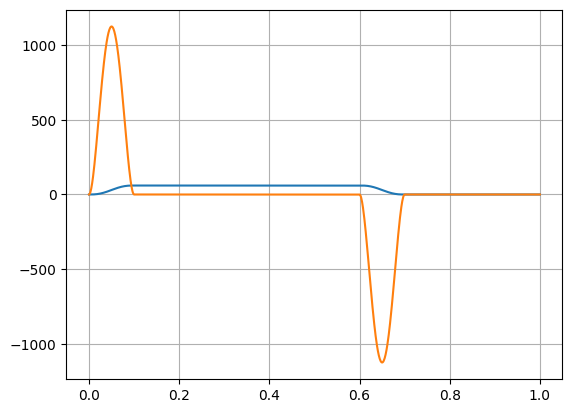

In [154]:
def smoothstep_quintic(x):
    # x assumed in [0,1]
    return x*x*x*(x*(x*6 - 15) + 10)

def smooth_step(t, t0, tau):
    x = (t - t0) / tau
    x = np.clip(x, 0.0, 1.0)
    return smoothstep_quintic(x)

def dsmooth_step_dt(t, t0, tau):
    x = (np.asarray(t, dtype=float) - t0) / tau
    return np.where((x > 0.0) & (x < 1.0), 30.0 * x*x * (x - 1.0)*(x - 1.0) / tau, 0.0)

def smooth_pulse(t, t_start, t_end, tau = 1e-4):
    return (1 - smooth_step(t, t_end, tau)) * smooth_step(t, t_start, tau)

def dsmooth_pulse(t, t_start, t_end, tau=1e-4):
    return ((1 - smooth_step(t, t_end, tau)) * dsmooth_step_dt(t, t_start, tau)
            - dsmooth_step_dt(t, t_end, tau) * smooth_step(t, t_start, tau))

def qv(t, t_start, t_end, tau=1e-4):
    q0 = point_source_Q0
    return q0[:] * smooth_pulse(t, t_start, t_end, tau)/L**1  # (ns, len(t)) if t is vector

def dqv(t, t_start, t_end, tau=1e-4):
    q0 = point_source_Q0
    return q0[:] * dsmooth_pulse(t, t_start, t_end, tau)/L**1 # (ns, len(t))

tmax = 1.
tau = .1
ts = np.linspace(0, tmax, 1000, endpoint=True)
qs = qv(ts, t_start = 0, t_end = 3*tmax/5, tau = tau)
dqs = dqv(ts, t_start = 0, t_end = 3*tmax/5, tau = tau)
plt.plot(ts,qs.T)
plt.plot(ts,dqs.T)
plt.grid(True)
plt.show()
q = lambda t: qv(t, t_start = 0, t_end = 5*tmax/3, tau = tau).squeeze()
dq = lambda t: dqv(t, t_start = 0, t_end = 5*tmax/3, tau = tau).squeeze()

SOURCE_INPUT_MODE = "rate"

def source_input_kind():
    mode = str(SOURCE_INPUT_MODE).strip().lower().replace("-", "_")
    if mode in {"rate", "q", "source_rate"}:
        return "rate"
    if mode in {"rate_derivative", "dq", "derivative", "source_rate_derivative"}:
        return "rate_derivative"
    raise ValueError("SOURCE_INPUT_MODE must be 'rate'/'q' or 'rate_derivative'/'dq'")

def source_forcing(t):
    kind = source_input_kind()
    return q(t) if kind == "rate" else dq(t)

In [155]:
# Domain setup
xmin, xmax = -D/2, D/2 # [m]

xmin_d, xmax_d = xmin/L, xmax/L

bnd_labels = {
    'left': lambda x: np.isclose(x[0], xmin_d),
    'right': lambda x: np.isclose(x[0], xmax_d),
    }

In [156]:
def meshline_geometric_symmetric(x0, xL, N, q):
    if N % 2 != 0:
        raise ValueError("N must be even for symmetric grading")
    L = xL - x0
    N2 = N // 2

    if abs(q - 1.0) < 1e-14:
        return np.linspace(x0, xL, N + 1)

    h0 = (L/2) * (q - 1.0) / (q**N2 - 1.0)
    h = h0 * q**np.arange(N2)
    x_left = np.concatenate(([0.0], np.cumsum(h)))  # includes 0 and (about) L/2

    # mirror nodes about L/2: exclude the midpoint to avoid duplication
    x_right = L - x_left[-2::-1]  # start from node before midpoint down to 0

    x = x0 + np.concatenate([x_left, x_right])
    x[-1] = xL
    return x

-500000.0 500000.0


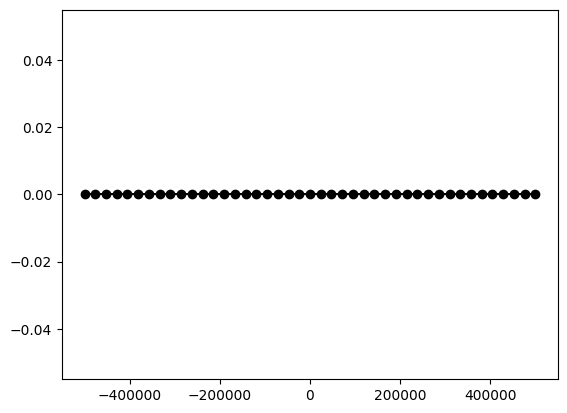

In [157]:
mesh_elements = 41+1
xcoords = np.linspace(xmin_d, xmax_d, mesh_elements + 1)
# xcoords = meshline_geometric_symmetric(xmin_d, xmax_d, mesh_elements, 1.15)
print(np.amin(xcoords),np.amax(xcoords))
mesh = MeshLine(xcoords)

mesh = mesh.with_boundaries(bnd_labels)
left_facets = mesh.boundaries['left']
right_facets = mesh.boundaries['right']

draw(mesh)
plt.show()

## Constitutive law

Plane-strain linear elasticity through $\sigma'_{ij}(E_{kl})$ with
Lamé parameters derived from $K_b$ and $\nu$.


In [158]:
def sij_core(E_kl, x_type):
    dim = E_kl.shape[-1]
    if dim == 2:
        batch_shape = E_kl.shape[:-2]
        E_kl_3D = np.zeros(batch_shape + (3, 3), dtype=E_kl.dtype)
        E_kl_3D[..., :dim, :dim] = E_kl
    elif dim == 3:
        E_kl_3D = E_kl
    else:
        raise ValueError("dim must be 1, 2 or 3")
    
    trE = np.trace(E_kl_3D, axis1=-2, axis2=-1)[..., None, None]
    I = np.eye(3, dtype=E_kl_3D.dtype)

    s3 = 2.0 * mu * E_kl_3D + lam * trE * I  # fully broadcasted

    return s3[..., :dim, :dim]   # slice back if dim==2

def Sij(E, x_type):
    """Wrapper that preserves the axis order of E."""
    E = np.asarray(E)
    if E.ndim < 2 or E.shape[0] != E.shape[1] or E.shape[0] not in (2, 3):
        raise ValueError(f"Expected (2,2,...) or (3,3,...), got {E.shape}")

    # move matrix axes (0,1) → (-2,-1), compute, move back
    E_last = np.moveaxis(E, (0, 1), (-2, -1))
    S_last = sij_core(E_last, x_type)
    return np.moveaxis(S_last, (-2, -1), (0, 1))

## Finite-element assembly

Mixed $v{-}r{-}u{-}p$ formulation with $P_2{-}P_2{-}P_2{-}P_1$ line
elements. The bilinear forms assemble the descriptor mass matrix $E$,
the stiffness/transport operator $A$, and Robin boundary contributions.
After Dirichlet BC rows are cleared the system is augmented with a
single scalar slip DOF whose RHS is $\dot s = |v_2(L)|$ (regularised).


In [159]:
dim = 2
intorder = 4

element_v = ElementLineP2()
element_r = ElementLineP2()
element_u = ElementLineP2()
element_p = ElementLineP1()

# element_v = ElementLineP1()
# element_r = ElementLineP1()
# element_u = ElementLineP1()
# element_p = ElementLineP1()

# element_v = ElementLineP1()
# element_r = ElementLineP1()
# element_u = ElementLineP1()
# element_p = ElementLineP0()

el_v = ElementVector(element_v, dim=dim)
# el_r = element_r
el_r = ElementVector(element_r, dim=dim)
el_u = ElementVector(element_u, dim=dim)
el_p = element_p

mixed_element = ElementComposite(el_v, el_r, el_u, el_p)
basis = Basis(mesh, mixed_element, intorder=intorder)
basis_boundary = FacetBasis(mesh, mixed_element, intorder=intorder)
fbasis_left = FacetBasis(mesh, mixed_element, intorder=intorder, facets=left_facets)
fbasis_right = FacetBasis(mesh, mixed_element, intorder=intorder, facets=right_facets)

@BilinearForm
def varform_lhs(dv, dr, du, dp, δv, δr, δu, δp, w):
    return ρ11 * dot(dv, δv) + ρ22 * dot(dr, δr) + ρ12 * dot(dv, δr) + ρ12 * dot(dr, δv) + dot(du, δu) + dp * δp

def make_sym(gradu):
    o = np.zeros((2, 2, *gradu.shape[2:]), dtype=gradu.dtype)
    o[0, 0] = gradu[0, 0]          # du1/dx
    o[0, 1] = 0.5 * gradu[1, 0]    # 1/2 du2/dx
    o[1, 0] = 0.5 * gradu[1, 0]
    return o

def my_sym_grad(u):
    tt = grad(u)
    return make_sym(tt)
# 
@BilinearForm
def varform_rhs(v, r, u, p, δv, δr, δu, δp, w):
    Eps_kl = my_sym_grad(u)
    Su_ij = Sij(Eps_kl, "quad")
    dEps_kl = my_sym_grad(v)
    Sv_ij = ηs * Sij(dEps_kl, "quad")
    I = np.eye(Eps_kl.shape[0])[:, :, None, None] * np.ones_like(Eps_kl)
    S_ij = Su_ij + Sv_ij - α * I * p
    term_1 = + ddot(S_ij, my_sym_grad(δv)) + b * dot(r, δr) - dot(v, δu)
    term_2 = - dot(p, grad(δr)[0,0]) + M * dot(α * grad(v)[0,0] + grad(r)[0,0], δp)
    return term_1 + term_2

@BilinearForm
def varform_robin(v, r, u, p, δv, δr, δu, δp, w):
    c_vv1, c_vv2, c_vu1, c_vu2, c_r = w.params
    # print(r.shape,w.n.shape)
    rn = r[0] #* w.n #dot(r, w.n)
    δrn = δr[0]# * w.n #dot(δr, w.n)
    term1 = (c_vv1 * v[0] + c_vu1 * u[0]) * δv[0] 
    term1+= (c_vv2 * v[1] + c_vu2 * u[1]) * δv[1] 
    term2 = c_r * rn * δrn
    return term1 + term2

@BilinearForm
def varform_frictional_part(v, r, u, p, δv, δr, δu, δp, w):
    n = w.n
    Eps_kl = my_sym_grad(u)
    Su_ij = Sij(Eps_kl, "quad")
    dEps_kl = my_sym_grad(v)
    Sv_ij = ηs * Sij(dEps_kl, "quad")
    I = np.eye(Eps_kl.shape[0])[:, :, None, None] * np.ones_like(Eps_kl)
    S_ij = Su_ij + Sv_ij - α * I * p
    # On a 1D boundary aligned with x, traction is t = sigma * n,
    # so the tangential component is t2 = sigma12 * n.
    s12_t = S_ij[0,1]
    t2 = s12_t * n
    return t2 * δv[1]

@BilinearForm
def varform_force(fv, fr, fu, fp, δv, δr, δu, δp, w):
    return + dot(fv + fu, δv) + dot(fr, δr)

E = asm(varform_lhs, basis)
Abulk = - asm(varform_rhs, basis)
Abndr_left = - asm(varform_robin, fbasis_left, params=robin_left)
Abndr_right = - asm(varform_robin, fbasis_right, params=robin_right)
A = Abulk + Abndr_left + Abndr_right

@BilinearForm
def varform_effective_traction(v, r, u, p, δv, δr, δu, δp, w):
    return -α * p * dot(w.n, δv)

A_eff_right = asm(varform_effective_traction, fbasis_right)
A = A + A_eff_right

dofs_left  = basis.get_dofs('left').all(["u^1^1", "u^2^1", "u^1^2", "u^2^2"])
Bbndr_force_left = - asm(varform_force, fbasis_left)[:, dofs_left]
dofs_right  = basis.get_dofs('right').all(["u^1^1", "u^2^1", "u^1^2", "u^2^2"])
Bbndr_force_right = - asm(varform_force, fbasis_right)[:, dofs_right]

ndofs = basis.N
print(A_eff_right)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2 stored elements and shape (553, 553)>
  Coords	Values
  (294, 300)	-0.6
  (295, 300)	-0.6


In [160]:
@BilinearForm
def varform_t1(v, r, u, p, δv, δr, δu, δp, w):
    n = w.n
    Eps_kl = my_sym_grad(u)
    Su_ij = Sij(Eps_kl, "quad")
    dEps_kl = my_sym_grad(v)
    Sv_ij = ηs * Sij(dEps_kl, "quad")
    S_ij = Su_ij + Sv_ij
    # On a 1D boundary aligned with x, the normal traction is t1 = sigma11 * n.
    s11_eff_t = S_ij[0,0]
    t1 = s11_eff_t * n
    return t1 * δv[0]
t1_left = asm(varform_t1, fbasis_left)
t1_right = asm(varform_t1, fbasis_right)
print(t1_left.shape)

(553, 553)


In [161]:
def get_atol(atol_fields):
    ids = basis.split_indices()
    atol = np.zeros(basis.N)
    for i, idx in enumerate(ids):
        atol[idx] = atol_fields[i]
    return atol

In [162]:
dx = (np.amax(mesh.p) - np.amin(mesh.p)) / mesh_elements
# sources_RMS_width = .5 * dx
sources_RMS_width = 1.5 * dx
nsrc = len(point_source_loc)
if sources_RMS_width > 0:
    Bp_full = lil_matrix((ndofs, nsrc))
    sigma = sources_RMS_width
    for j, (c) in enumerate(point_source_loc):
        @LinearForm
        def smooth_dirac(δv, δr, δu, δp, w):
            r2 = np.sum((w.x - c[:, None, None])**2, axis = 0)
            g = np.exp(-r2 / 2 / sigma**2)
            # normalize so ∫g dx ≈ 1
            norm_factor = (sigma * np.sqrt(2 * np.pi))**w.x.shape[0]
            return g / norm_factor * δp / dx
        fvec = asm(smooth_dirac, basis)
        @LinearForm
        def avg(δv, δr, δu, δp, w):
            return 1. * δp
        Cp = asm(avg, basis)
        int_g = Cp @ fvec
        print(f"Source {j}: ∫ g ≈ {int_g:.5f} (should be ≈ 1.0)")
        Bp_full[:, j] = fvec.reshape(-1, 1)/L

elif sources_RMS_width == 0:
    Bp_full = lil_matrix((ndofs, nsrc))
    p_ndofs = basis.split_indices()[3]
    basis_p = Basis(mesh, el_p, intorder=intorder)
    for j, xs in enumerate(point_source_loc):
        tmp = basis_p.point_source(xs)
        Bp_full[p_ndofs, j] = tmp
else:
    raise ValueError("Gaussian RMS width cannot be negative.")
B = M * Bp_full.tocsr()


Source 0: ∫ g ≈ 1.00000 (should be ≈ 1.0)


In [163]:
user_to_skfem = {
            "v1": "u^1^1",
            "v2": "u^2^1",
            "r1": "u^1^2",
            "r2": "u^2^2",
            "u1": "u^1^3",
            "u2": "u^2^3",
            "p": "u^4",
        }

E_D = E.tolil(); A_D = A.tolil(); B_D = B.tolil()
dofs_D = np.array([],dtype=np.int32)
for field, sides in bc_dofs.items():
    for side, value in sides.items():
        field_skfem = user_to_skfem.get(field)
        dofs_D = np.append(dofs_D, basis.get_dofs(side).all(field_skfem))
E_D[dofs_D, :] = 0.
E_D[:, dofs_D] = 0.
E_D[dofs_D, dofs_D] = 1.
A_D[dofs_D, :] = 0.
A_D[:, dofs_D] = 0.
B_D[dofs_D] = 0.
E_D = E_D.tocsr(); A_D = A_D.tocsr(); B_D = B_D.tocsr()

# ── Augment with accumulated slip DOF: ṡ = |v₂| ──
from scipy.sparse import block_diag as sp_block_diag, vstack as sp_vstack, csr_matrix as csr
slip_idx = ndofs                       # index of the new slip DOF
eps_slip = 1e-20 / L                   # regularisation for |v₂|
slip_rate_floor = np.sqrt(eps_slip)    # subtract so ṡ = 0 when v₂ = 0

E_D = sp_block_diag([E_D, csr(np.array([[1.]]))], format='csr')
A_D = sp_block_diag([A_D, csr(np.array([[0.]]))], format='csr')
B_D = sp_vstack([B_D, csr((1, B_D.shape[1]))], format='csr')

# Pre-build Jacobian template with sparsity slot for d|v₂|/dv₂
A_D_jac_template = A_D.tolil()
A_D_jac_template[slip_idx, 0] = 0.     # ensure lil has the row allocated
A_D_jac_template = A_D_jac_template.tocsr()

ndofs_aug = ndofs + 1
print(f"Augmented system: {ndofs} physics + 1 slip = {ndofs_aug} DOFs")

Augmented system: 553 physics + 1 slip = 554 DOFs


In [164]:
sides = ["left", "right"]
TPloc = {"left": 0, "right": 0}
TPloc_idx = {"left": 0, "right": 0}
for side in sides:
    t1_node = basis.get_dofs(side).all(user_to_skfem["v1"])[0]
    t2_node = basis.get_dofs(side).all(user_to_skfem["v2"])[0]
    v1_node = t1_node
    v2_node = t2_node
    u1_node = basis.get_dofs(side).all(user_to_skfem["u1"])[0]
    u2_node = basis.get_dofs(side).all(user_to_skfem["u2"])[0]
    p_node  = basis.get_dofs(side).all(user_to_skfem["p"])[0]
    TPloc_idx[side]=[t1_node, t2_node, v1_node, v2_node, u1_node, u2_node, p_node]
    T1 = np.zeros(ndofs,dtype = np.int32); T1[t1_node] = 1
    T2 = np.zeros(ndofs,dtype = np.int32); T2[t2_node] = 1
    Pv1 = np.zeros(ndofs,dtype = np.int32); Pv1[v1_node] = 1
    Pv2 = np.zeros(ndofs,dtype = np.int32); Pv2[v2_node] = 1
    Pu1 = np.zeros(ndofs,dtype = np.int32); Pu1[u1_node] = 1
    Pu2 = np.zeros(ndofs,dtype = np.int32); Pu2[u2_node] = 1
    Pp = np.zeros(ndofs,dtype = np.int32); Pp[p_node] = 1
    TPloc[side]=[T1, T2, Pv1, Pv2, Pu1, Pu2, Pp]

# def set_friction(rhs, z, sides = []):
#     if len(sides) == 0: return rhs
#     for side in sides:
#         T1, T2, Pv1, Pv2, Pu1, Pu2, Pp = TPloc[side]
#         u_slip = Pu2 @ z
#         v_slip = Pv2 @ z
#         t1_tilde = T1 @ rhs
#         p = Pp @ rhs
#         t1_eff_tilde = (t1_tilde + α * p)
#         t1_eff_bar = s11_eff_0
#         if side == "left": t1_eff_bar*=-1.
#         t2_tilde = mu_fric(u_slip, v_slip) * (t1_eff_bar + t1_eff_tilde) - mu_fric(0, 0) * t1_eff_bar
#         sgn = -mysign(v_slip)
#         t2_tilde*= sgn
#         rhs[t2_node]+= t2_tilde
#     return rhs

In [165]:
def rhs_plant(t,y):
    rhs_sm = A_D @ y
    if ENABLE_INJECTION:
        # Choose whether the PDE sees the source-rate history q(t) or its
        # derivative dq(t).  See SOURCE_INPUT_MODE in the run-config cell.
        rhs_sm = rhs_sm + B_D @ source_forcing(t)
    # rhs_sm+= Bbndr_force_left @ force_left(t)
    # rhs_sm+= Bbndr_force_right @ force_right(t)
    # rhs_sm[dofs_D] = 0.

    # Slip rate equation: ṡ = |v₂| 
    v2 = y[vtt_idx]
    rhs_sm[slip_idx] = np.abs(v2)#np.sqrt(v2**2 + eps_slip) - slip_rate_floor
    rhs_sm[dofs_D] = 0.

    return rhs_sm 

def rhs(t, z):
    rhs = rhs_plant(t,z)
    # print(f'shapes:{np.shape(z)}')
    return rhs

def with_progress(fun, t0, tf, step_percent=1):
    last = {"p": -1}

    def wrapped(t, y):
        p = int(100 * (t - t0) / (tf - t0))
        if p >= last["p"] + step_percent:
            last["p"] = p
            print(f"\rProgress: {p:3d}%", end="", flush=True)
        return fun(t, y)

    return wrapped

## Plotting helpers

Reusable routines to split the mixed solution vector into the
$v{-}r{-}u{-}p$ fields and to recover the nodal stress/strain history
from the stored state trajectory.


In [166]:
def split_sol(zs):
    (v, vb), (r, rb), (u, ub), (p, pb) = basis.split(zs)
    v = [vi[vib.nodal_dofs[0]] for vi, vib in vb.split(v)]
    r = [ri[rib.nodal_dofs[0]] for ri, rib in rb.split(r)]
    u = [ui[uib.nodal_dofs[0]] for ui, uib in ub.split(u)]
    if len(pb.nodal_dofs) == 0:
        p_ext = np.pad(p, ((1, 1), (0, 0)), mode="edge")
        p = 0.5 * (p_ext[1:, :] + p_ext[:-1, :])
    else:
        p = p[pb.nodal_dofs[0]]  # (n_nodes, ...) — same shape as v/r/u entries
    return np.array([*v[:dim], *r[:dim], *u[:dim], p])

# m_tri = MeshTri().init_tensor(np.linspace(xmin, xmax, mesh_elements + 1), np.linspace(ymin, ymax, mesh_elements + 1))

def plot_solution(z, v_min, v_max):
    v1, v2, r1, r2, u1, u2, p = z
    fig, ax = plt.subplots(2, 2, figsize=(8, 4))
    # Plot v1, v2
    i = 0; j = 0
    tcf = ax[i, j].plot(xcoords * L, v1, "b", label = "$v_1$")
    tcf = ax[i, j].plot(xcoords * L, v2, "r", label = "$v_2$")
    ax[i, j].legend()
    if min(v_min[0],v_min[1]) != max(v_max[0],v_max[1]):
        ax[i, j].set_ylim(min(v_min[0],v_min[1]),max(v_max[0],v_max[1]))
    ax[i, j].set_xlabel("$x$")
    
    # Plot u1, u2
    i = 0; j = 1
    tcf = ax[i, j].plot(xcoords * L, u1, "b", label = "$u_1$")
    tcf = ax[i, j].plot(xcoords * L, u2, "r", label = "$u_2$")
    ax[i, j].legend()
    if min(v_min[4],v_min[5]) != max(v_max[4],v_max[5]):
        ax[i, j].set_ylim(min(v_min[4],v_min[5]),max(v_max[4],v_max[5]))
    ax[i, j].set_xlabel("$x$")
    
    # Plot r1, r2
    i = 1; j = 0
    tcf = ax[i, j].plot(xcoords * L, r1, "b", label = "$r_1$")
    tcf = ax[i, j].plot(xcoords * L, r2, "r", label = "$r_2$")
    ax[i, j].legend()
    if min(v_min[2],v_min[3]) != max(v_max[2],v_max[3]):
        ax[i, j].set_ylim(min(v_min[2],v_min[3]),max(v_max[2],v_max[3]))
    ax[i, j].set_xlabel("$x$")

    # Plot p
    i = 1; j = 1
    tcf = ax[i, j].plot(xcoords * L, p, "b", label = "$p$")
    ax[i, j].legend()
    if v_min[6] != v_max[6]:
        ax[i, j].set_ylim(v_min[6], v_max[6])
    ax[i, j].set_xlabel("$x$")
    
    plt.tight_layout()

def plot_tensor(tensor, v_min_t, v_max_t, name="tensor"):
    n, m, _ = tensor.shape
    fig, ax = plt.subplots(n, m, figsize=(8, 4))
    for i in range(n):
        for j in range(m):
            tcf = ax[i, j].plot(xcoords * L, tensor[i,j])
            ax[i, j].set_title(f"${name}_{{{i+1}{j+1}}}$")
            if v_min_t[i,j] != v_max_t[i,j]:
                ax[i, j].set_ylim(v_min_t[i,j], v_max_t[i,j])
            # ax[i, j].set_aspect('equal')
    plt.tight_layout()

def plot_point_hist(ss, ss_eff, zs_split, pids):
    fig, ax = plt.subplots(len(pids), 3, figsize=(10, 6))
    for i, pid in enumerate(pids):
        xpid = np.round(xcoords[pid] * L,1)
        ax[i, 0].plot(ts, ss[:,0,0,pid],label="$\\sigma_{11}$ @ x="+str(xpid))
        ax[i, 0].plot(ts, zs_split[:,6,pid],label="$p$ @ x="+str(xpid))
        ax[i, 0].plot(ts, ss_eff[:,0,0,pid],label="$\\sigma'_{11}$ @ x="+str(xpid))
        ax[i, 0].legend()
        ax[i, 0].grid(True)
        ax[i, 0].set_xlabel("$t$")
        ax[i, 1].plot(ts, ss[:,0,1,pid],label="$\\sigma_{12}$ @ x="+str(xpid))
        ax[i, 1].plot(ts, ss_eff[:,0,1,pid],label="$\\sigma'_{12}$ @ x="+str(xpid))
        ax[i, 1].legend()
        ax[i, 1].grid(True)
        ax[i, 1].set_xlabel("$t$")
        μmob = np.divide(ss[:,0,1,pid], ss_eff[:,0,0,pid],
                       out=np.zeros_like(ss[:,0,1,pid]),
                       where=ss_eff[:,0,0,pid] != 0)
        # print(np.amax(μmob))
        ax[i, 2].plot(ts, μmob,label="$\\mu_{mob}$ @ x="+str(xpid))
        ax[i, 2].legend()
        ax[i, 2].grid(True)
        ax[i, 2].set_xlabel("$t$")
    plt.tight_layout()


In [167]:
def get_grad_QM(ubasis_scalar):
        """
        Computes the weak gradient and mass matrices.
        """
        @BilinearForm
        def ds_dxi(s, δs, w):
            return grad(s)[w['i']] * δs

        @BilinearForm
        def mass(s, δs, w):
            return s * δs
    
        Q = [ds_dxi.assemble(ubasis_scalar, i=i)  for i in range(1)]
        M = mass.assemble(ubasis_scalar)
        M_lu = splu(M.tocsc())
        return Q, M, M_lu

(_, _), (_, _), (u, ub), (_, _) = basis.split(np.zeros(ndofs))
ubasis_scalar = ub.split_bases()[0]
gradu_QM = get_grad_QM(ubasis_scalar)

def get_gradu(u_components):
        """
        Computes the weak gradients at mesh nodes.
        u_components: list/array of length dim, each element shape (ndofs,)
        Returns: gradu with shape (dim, dim, ndofs)
                gradu[i, j, :] = ∂u_i/∂x_j (weak gradient)
        """
        Q, _, M_lu = gradu_QM

        # Stack components into one 2D array: (dim, ndofs)
        U = np.stack(u_components, axis=0)          # (dim, ndofs)

        grads_per_j = []
        for j in range(1):
            # Q[j] @ U.T: (ndofs, dim) — all components at once
            rhs = Q[j] @ U.T                         # (ndofs, dim)
            sol = M_lu.solve(rhs)                    # (ndofs, dim)
            grads_per_j.append(sol.T)                # (dim, ndofs)

        # grads_per_j: list of length dim, each (dim, ndofs)
        # gradu: (dim, dim, ndofs)
        gradu = np.stack(grads_per_j, axis=1)
        return gradu

def compute_stress_strain(zs, only_nodal = True):
    ss = []; es = [];
    for t_ind, z in enumerate(zs.T):
        (v, vb), (_, _), (u, ub), (p, pb) = basis.split(z)            
        components = ub.split(u)
        u_components = [comp[0] for comp in components]   # [u_x, u_y, (u_z)]
        gradu = get_gradu(u_components)
        
        components = ub.split(v)
        v_components = [comp[0] for comp in components]   # [u_x, u_y, (u_z)]
        gradv = get_gradu(v_components)
        
        x_type = "node_all"
        if only_nodal:
            gradu = gradu[:, :, ubasis_scalar.nodal_dofs[0]]
            gradv = gradv[:, :, ubasis_scalar.nodal_dofs[0]]
            x_type = "node"
        
        e = make_sym(gradu)
        de = make_sym(gradv)
        s = Sij(e, x_type) + ηs * Sij(de, x_type)
        
        ss.append(s)
        es.append(e)
    return np.array(ss), np.array(es)

## Friction as an NCP

The second-order friction cone
$\mathcal{K}_\mu = \{r : |r_T| \le \mu\,r_N\}$ is recast through
the Fischer–Burmeister function
$\phi_{\text{FB}}(a,b) = a + b - \sqrt{a^2 + b^2}$ into a residual
whose semismooth Newton iterations live alongside the poroelastic
block in `ImplicitEquationSolver`.

To test pressure-triggered slip, the prestress shift is set
*just inside* the cone using a nudge factor $\varepsilon$:

$$
w_0 \;=\; -\,\sigma_{11}^{\text{eff}}\,\mu(0)\,(1-\varepsilon),
\qquad \varepsilon = 10^{-3}.
$$

The endpoint projection uses natural-map inactive handling so the
effective contact cone, not an exact floating-point sign of the gap,
decides whether the prestressed contact remains active.


In [168]:
def mu_fric(slip, slip_rate):
    slip_eff = max(slip, 0)  # no healing, only slip weakening
    a=mu_res*(1. -Dmu/mu_res*np.exp(-slip_eff/Dc))
    return a

def mu_(z):
    _, _, vtn_idx, vtt_idx, u1n_idx, u2t_idx, _ = TPloc_idx["right"]
    slip_rate = z[vtt_idx]
    slip = z[slip_idx]                 # accumulated slip from augmented state
    return mu_fric(slip, slip_rate)

def dmu_dy_(z):
    out = np.zeros_like(z, dtype=float)
    slip = z[slip_idx]
    if slip > 0.0:
        out[slip_idx] = (Dmu / Dc) * np.exp(-slip / Dc)
    return out
    
def mysign(x, epsilon=1e-20):
    # a = np.tanh(x / epsilon)
    a = x/np.sqrt(x**2 + epsilon/L)
    return a*0+1

# Initial condition
def IC(xn):
    x = xn[0] * L
    v = 1.e-6 * (x + D / 2) / D
    return v / L

y0 = np.zeros(ndofs)
(vi, vb), (ri, rb), (ui, ub), (pi, pb) = basis.split(y0)
(v1i, vb1), (v2i, vb2) = vb.split(y0)
idx2 = vb.split_indices()[1]
v20 = vb1.project(IC)
vi[idx2]=v20*0
idx = basis.split_indices()[0]
y0[idx] = vi*0

# Augment y0 with initial slip = 0
y0 = np.append(y0, 0.0)



In [169]:
u_idx = basis.split_indices()[2]
# print(u_idx)

## Simulation configuration and boundary geometry

Fix the horizon, set an initial step suggestion, and map the right-wall
DOFs into the contact frame `(u_N, u_T)` expected by `build_projected_radau_contact`.
The loading pulse $Q(t)$ is previewed but the external body force is
disabled for this demo — the whole drive comes from the prestress shift
in the cone.

`h0_init` is only the controller's *starting guess*; the embedded
error estimate of Radau IIA s=2 then drives the step size on its own.


mechanical dt_crit 0.00408575631104491
operational smoother tau 0.01634302524417964
source input mode rate_derivative -> dq(t)
integrated source magnitude [0.06]
source history amplitude [0.06]


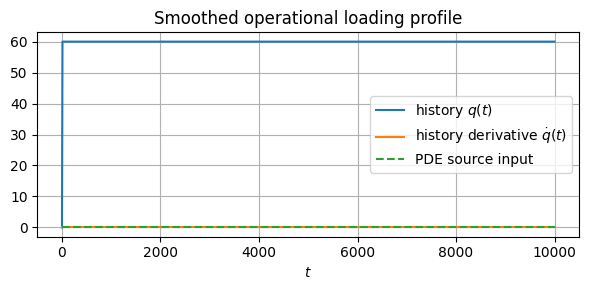

In [170]:
# ─ Run mode ──────────────────────────────────────────────────────────────
# Toggle adaptive embedded-error stepping. See the markdown cell below for
# the multiscale subtleties of running Radau IIA s=2 in adaptive mode on
# this damped-wave / slow-slip problem.
USE_ADAPTIVE = True
ENABLE_INJECTION = True

# Source interpretation:
#   "rate"            -> the PDE receives q(t), a signed injection/extraction rate.
#   "rate_derivative" -> the PDE receives dq(t); q(t) is a smooth cumulative
#                         source amplitude, so shut-in of a top-hat produces
#                         an opposite-sign pulse.
SOURCE_INPUT_MODE = "rate_derivative"

# Time horizon + operational loading schedule.  With k = 1e-14 m^2 the
# center-to-boundary diffusion scale is O(30 days), so use a single long
# run but make the startup/shut-in ramps resolvable by the adaptive solver.
day = 24.0 * 3600.0
tmax = 1e4#10.0# * day
load_t_end = tmax            # shut-in lands at the end of t_span; no post-shut-in recovery interval inside the 5 s run
tau_load = 0.5e-3 #* day          # operational ramp, not mechanical CFL scale
_source_kind = source_input_kind()
if _source_kind == "rate":
    # q(t) is the actual source rate.  Normalize the plateau so integrating
    # over the operation gives point_source_total_Q.
    point_source_Q0 = point_source_total_Q / load_t_end
elif _source_kind == "rate_derivative":
    # dq(t) is the actual source.  q(t) is the smooth cumulative amplitude.
    # If the top-hat ramps down within t_span, dq(t) applies an opposite pulse.
    point_source_Q0 = point_source_total_Q.copy()
else:
    raise AssertionError(_source_kind)
h0_init = tau_load / 20.0     # first adaptive trial must not skip the ramp
n_steps_init = int(np.ceil(tmax / h0_init))
t_span = (0.0, tmax)

# Fine output sample grid (used only if the solver passes it along)
# t_eval = np.arange(0.0, tmax, D / L / vw / 100)

# Contact-frame indices on the right boundary -----------------------------
_, _, vtn_idx, vtt_idx, u1n_idx, u2t_idx, pt_idx = TPloc_idx["right"]

contact_vel_C = lil_matrix((2, ndofs_aug), dtype=float)
contact_vel_C[0, vtn_idx] = -1.0
contact_vel_C[1, vtt_idx] = 1.0
contact_vel_C = contact_vel_C.tocsr()

# Right-wall Signorini gap only: g = -u1(right). Opening leftward gives g > 0.
# Tangential slip/velocity is handled by contact_vel_C; do not include it in C_extract.
contact_gap_C = lil_matrix((1, ndofs_aug), dtype=float)
contact_gap_C[0, u1n_idx] = -1.0
contact_gap_C = contact_gap_C.tocsr()

contact_B = contact_vel_C.T.tocsr()

contact_blocks = [dict(vel_normal_idx=0, vel_tangential_idx=[1], mu=mu_, dmu_dy=dmu_dy_)]
contact_vel_idx = np.array([vtn_idx, vtt_idx], dtype=int)
contact_other_idx = np.array(
    sorted(set(range(ndofs_aug)) - set(contact_vel_idx.tolist())),
    dtype=int,
)
contact_component_slices = [contact_vel_idx, contact_other_idx]

# Smoothed operational source-rate history (injected through rhs_plant) ----
dx_mesh = (np.amax(mesh.p) - np.amin(mesh.p)) / mesh_elements
dt_crit = dx / vw
tau = 4 * dt_crit
print("mechanical dt_crit", dt_crit)
print("operational smoother tau", tau)
print("source input mode", SOURCE_INPUT_MODE, "->", "q(t)" if _source_kind == "rate" else "dq(t)")
print("integrated source magnitude", point_source_total_Q.ravel())
print("source history amplitude", point_source_Q0.ravel())
source_steps_per_tau = 8.0
if not USE_ADAPTIVE and h0_init > tau / source_steps_per_tau:
    n_steps_init = int(np.ceil(tmax / (tau / source_steps_per_tau)))
    h0_init = tmax / n_steps_init
    print(f"refined fixed step for source ramp: h0={h0_init:.4g}, n_steps={n_steps_init}, tau/h0={tau / h0_init:.2f}")
q = lambda t: qv(t, t_start=0, t_end=load_t_end, tau=tau).reshape(-1)
dq = lambda t: dqv(t, t_start=0, t_end=load_t_end, tau=tau).reshape(-1)

ts_load = np.linspace(0, tmax, 1000, endpoint=True)
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(ts_load, q(ts_load).T, label=r"history $q(t)$")
ax.plot(ts_load, dq(ts_load).T, label=r"history derivative $\dot q(t)$")
ax.plot(ts_load, np.asarray(source_forcing(ts_load)).T, "--", label=r"PDE source input")
ax.set_xlabel(r"$t$")
ax.set_title("Smoothed operational loading profile")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

# Augmented Jacobian template: now that vtt_idx is bound we can pre-allocate
# the slip-row slot so the per-step Jacobian build does not trip the
# scipy 'changing sparsity structure' warning.
# Pre-allocate the slip-row slot with a tiny non-zero placeholder so that
# the subsequent tolil->tocsr conversion doesn't drop the explicit zero,
# which would force the per-step assignment to change the sparsity
# structure of the CSR copy and raise scipy's SparseEfficiencyWarning.
_jac_slot_placeholder = 1e-300
A_D_jac_template = A_D.tolil()
A_D_jac_template[slip_idx, 0] = _jac_slot_placeholder
A_D_jac_template[slip_idx, vtt_idx] = _jac_slot_placeholder
A_D_jac_template = A_D_jac_template.tocsr()

def rhs_jac_aug(t, y):
    J = A_D_jac_template.copy()
    v2 = y[vtt_idx]
    J[slip_idx, vtt_idx] = np.sign(v2)
    return J


In [171]:
# contacts=contact_blocks,
# C_extract=contact_gap_C,
# D_extract=contact_vel_C,
# B=contact_B

print(contact_blocks)

[{'vel_normal_idx': 0, 'vel_tangential_idx': [1], 'mu': <function mu_ at 0x7b5bfccde7a0>, 'dmu_dy': <function dmu_dy_ at 0x7b5bfc1f91c0>}]


## Radau IIA solve (toggleable adaptive vs fixed)

Set `USE_ADAPTIVE` in the configuration cell above to switch modes:

- `True`  → embedded-error adaptive controller; rtol/atol and
  `skip_error_indices` configured below to keep the controller from
  fighting L-stable damping of the poroelastic waves.
- `False` → constant `h0_init` over the whole horizon (the original
  fixed-step run).

Both modes use the same coupled-Newton path.

Two-stage Radau IIA (classical order 3, stage order 2, $L$-stable) is
routed through the coupled-Newton path:
`integrator_opts.update(stages=2, use_coupled_newton=True)` hands the
stacked $(s \cdot n)$ system to `ImplicitEquationSolver.solve` so the
Radau stages inherit the same WRMS-based semismooth Newton used by the
backward-Euler path. The per-DOF tolerance vector drives `nl_rtol = 0`
on reaction rows so the WRMS norm does not dilute the cone residual.

For $s=2$, Radau IIA exposes a true embedded error estimate via the
companion $\hat b = [1,0]$ — no Richardson extrapolation needed:

$$
\mathrm{err} \;=\; \bigl(e_s \;-\; \hat b^{T} A^{-1}\bigr)\,(Y - y),
\qquad p_{\mathrm{embedded}} = 1.
$$

The adaptive controller therefore uses exponent $1/(p+1) = 1/2$.
Around the slip-nucleation event the embedded estimate spikes (the
two stages straddle the stick→slip regime change), so the controller
is expected to **shrink $h$ aggressively at nucleation** and let it
grow back once the post-nucleation dynamics are smooth. The
`active_set_filter` would normally suppress this spike, but it relies
on `projection.regime()` which the NCP backend does not expose
(`IdentityProjection`) — embedded error sees the event directly.

Butcher tableau:


In [172]:
# Projected Radau contact backend (self-dual De Saxce, reported force reactions) ---
from solve_nivp.projected_radau_contact import build_projected_radau_contact

PROJECTED_CONTACT_LAW = 'fischer_burmeister'

friction_nudge = 1.0#1  # <1 stays inside the initial Coulomb cone; pressure is the perturbation

def contact_s0_force_vec(y):
    # Normal ray = -sigma_11_eff (compression is negative in the FEM).
    return np.array([s11_eff_0])  # constant effective prestress; αp correction is in the FE assembly

def contact_w0_force_vec(y, k):
    # Tangential prestress shifted just outside the Coulomb cone by the
    # nudge factor so the cone law must return a non-trivial reaction
    # at t = 0^+ and the slip regime engages immediately.
    nudge = friction_nudge
    return np.array([-s11_eff_0 * mu_fric(0.0, 0.0) * nudge])
def gap_func(y, k):
    # Right-wall Signorini gap, matching contact_gap_C.
    delta = np.asarray(y[u1n_idx]).ravel()

    return -delta  # gap = -u1(right), consistent with contact_gap_C

cs_projected = build_projected_radau_contact(
    A=E_D,
    rhs_smooth=rhs_plant,
    y0=y0,
    contacts=contact_blocks,
    C_extract=contact_gap_C,
    D_extract=contact_vel_C,
    B=contact_B,
    component_slices=contact_component_slices,
    # C_extract already encodes this same gap.  Leaving gap_func=None
    # lets the backend use the sparse analytic gap Jacobian instead of
    # finite-differencing a Python callback at every Newton refresh.
    gap_func=None,
    reported_reaction_units='force',
    get_s0=contact_s0_force_vec,
    get_w0=contact_w0_force_vec,
    rhs_jac=rhs_jac_aug,
    contact_law=PROJECTED_CONTACT_LAW,
    normal_r='auto',
    friction_r='auto',
    endpoint_inactive_handling='natural_map',
)
cs_ncp = cs_projected  # compatibility alias for the downstream diagnostics

# Per-DOF nonlinear tolerances: rtol = 0 on reaction rows kills the WRMS
# dilution gap documented in project_desaxce_fix.
n_aug_total = cs_ncp.y0.size
nl_atol_ncp = np.full(n_aug_total, 1e-8)
nl_rtol_ncp = np.full(n_aug_total, 1e-6)
nl_atol_ncp[ndofs_aug:] = 1e-10
nl_rtol_ncp[ndofs_aug:] = 0.0

# Warm-start r across steps; full Newton step for smooth slip-weakening.
solver_opts_ncp = dict(cs_ncp.solver_opts)
solver_opts_ncp.pop('cold_start_slices', None)
solver_opts_ncp['damped_step_fraction'] = 1.0
solver_opts_ncp['diagonal_regularization'] = 0.0
solver_opts_ncp.update(
    tol=1e-12,
    max_iter=50,
    rhs_jac=cs_ncp.rhs_jac,
    # SuperLU is faster than PETSc/MUMPS for this small serial 1D system.
    # Set to 'petsc' when explicitly comparing PETSc/MUMPS behavior.
    linear_solver='splu',
    # Kept for PETSc comparison runs; ignored by the SuperLU backend.
    petsc_reuse_steps=20,
)

# Route Radau IIA through the Breuling projected two-stage path.
integrator_opts_ncp = dict(cs_ncp.integrator_opts)
integrator_opts_ncp.update(stages=2, use_coupled_newton=True)

# Required output times: adaptive integrator must evaluate at each of these.
T_EVAL = np.linspace(0.0, tmax, 100)

solve_kwargs = dict(
    fun=cs_ncp.rhs,
    t_span=t_span,
    y0=cs_ncp.y0,
    A=cs_ncp.A,
    method='radau_iia',
    projection=cs_ncp.projection,
    solver='semismooth_newton',
    solver_opts=solver_opts_ncp,
    nl_atol=nl_atol_ncp,
    nl_rtol=nl_rtol_ncp,
    component_slices=cs_ncp.component_slices,
    integrator_opts=integrator_opts_ncp,
    h0=h0_init,
    dae_var_weight='auto',
    active_set_filter=False,
    t_eval=T_EVAL,
)

if USE_ADAPTIVE:
    # Loose rtol/atol + drop multivalued contact velocity (block 0) and
    # algebraic NCP reactions (last block) from the WRMS norm, otherwise
    # the L-stably-damped poroelastic waves get misread as truncation
    # error and the controller chokes h to 1e-10 at nucleation.
    solve_kwargs.update(
        adaptive=True,
        rtol=5e-3,
        atol=1e-4,
        skip_error_indices=[0, len(cs_ncp.component_slices) - 1],
        adaptive_opts=dict(
            h0=h0_init,
            h_max=1,#tau / 8.0,
            h_up=2.0,
            h_down=0.5,
        ),
    )
else:
    solve_kwargs.update(adaptive=False)

start = time.time()
t_ncp, y_ncp, h_ncp_hist, fk_ncp, info_ncp = solve_nivp.solve_ivp_ns(**solve_kwargs)
time_ncp = time.time() - start
mode_label = "adaptive" if USE_ADAPTIVE else "fixed-step"
n_steps_taken = len(t_ncp) - 1
h_arr = np.asarray(h_ncp_hist, dtype=float) if h_ncp_hist is not None else np.array([])
print(f"Projected Radau+{PROJECTED_CONTACT_LAW} law ({mode_label}) elapsed: {time_ncp:.2f} s")
print(f"  h0              : {h0_init:.4g} s")
print(f"  steps taken     : {n_steps_taken}")
if h_arr.size:
    print(f"  step range      : [{float(h_arr.min()):.3e}, {float(h_arr.max()):.3e}] s")
    print(f"  median step     : {float(np.median(h_arr)):.3e} s")
print(f"  reached t = {float(t_ncp[-1]):.6g}")
print(f"  t_eval requested: {T_EVAL}")
print(f"  t_eval actual   : {t_ncp}")

projected_radau_model = cs_projected.projected_radau_contact
h_last = float(h_arr[-1]) if h_arr.size else float(h0_init)
projected_radau_diagnostics = dict(
    last_stage_dpi=projected_radau_model.last_stage_dpi,
    last_stage_dmu=projected_radau_model.last_stage_dmu,
    last_delta_pi=projected_radau_model.last_delta_pi,
    last_total_pi=projected_radau_model.last_total_pi,
    last_total_effective_pi=projected_radau_model.last_total_effective_pi,
    last_reported_reaction=projected_radau_model.last_reported_reaction,
)
if projected_radau_model.last_total_pi is not None:
    print("  final Δπ⁺/h       :", projected_radau_model.last_total_pi / h_last)
    print("  final effective π⁺/h:", projected_radau_model.last_total_effective_pi / h_last)
    print("  reported reaction :", projected_radau_model.last_reported_reaction)


Projected Radau+fischer_burmeister law (adaptive) elapsed: 7.33 s
  h0              : 2.5e-05 s
  steps taken     : 99
  step range      : [2.500e-05, 9.333e-01] s
  median step     : 1.487e-01 s
  reached t = 10000
  t_eval requested: [    0.           101.01010101   202.02020202   303.03030303
   404.04040404   505.05050505   606.06060606   707.07070707
   808.08080808   909.09090909  1010.1010101   1111.11111111
  1212.12121212  1313.13131313  1414.14141414  1515.15151515
  1616.16161616  1717.17171717  1818.18181818  1919.19191919
  2020.2020202   2121.21212121  2222.22222222  2323.23232323
  2424.24242424  2525.25252525  2626.26262626  2727.27272727
  2828.28282828  2929.29292929  3030.3030303   3131.31313131
  3232.32323232  3333.33333333  3434.34343434  3535.35353535
  3636.36363636  3737.37373737  3838.38383838  3939.39393939
  4040.4040404   4141.41414141  4242.42424242  4343.43434343
  4444.44444444  4545.45454545  4646.46464646  4747.47474747
  4848.48484848  4949.49494949  

## Extract boundary histories

Strip the physics block from the augmented state, pull the scalar
slip trajectory from `slip_idx`, and split the reaction block
`y_ncp[:, ndofs_aug:]` into normal and tangential components for the
cone-trajectory plot.


In [173]:
ts = t_ncp
zs_ncp = y_ncp.T[:ndofs, :]                  # physics-only state
slip_hist = y_ncp[:, slip_idx]                # augmented slip DOF

# Reaction block: the projected Radau backend stores the reported
# (normal, tangential) reaction perturbation relative to the prestress
# shift w0. For this demo the normal load is
# carried entirely by the get_s0 offset, so r_hist[:, 0] is identically
# zero and r_hist[:, 1] holds the tangential stress drop Δτ(t) relative to
# the initial cone ray.
r_hist = cs_projected.reaction_history(y_ncp)
r_T_delta = r_hist[:, 1] if r_hist.shape[1] >= 2 else np.zeros_like(ts)

# Reconstruct the absolute tangential traction magnitude on the fault.
# w0 at t=0 was -s11*mu(0)*nudge; the live traction is w0 + Δτ in the
# reported-force convention. Taking |·| for the cone-strength comparison.
nudge = friction_nudge
tau_wall_abs = np.abs(-s11_eff_0 * mu_fric(0.0, 0.0) * nudge + r_T_delta)
mu_of_s = np.array([mu_fric(float(s), 0.0) for s in slip_hist])
fault_strength = mu_of_s * (r_hist[:, 0] + s11_eff_0)

# Split physical fields into (field, component, node) for boundary picks.
zs_split = split_sol(zs_ncp).transpose(2, 0, 1)
zs_split[:, :6, :] *= L
zs_split[:, 6, :] /= L

u2_right = zs_split[:, 5, -1]                 # u2 at right boundary
u2_left  = zs_split[:, 5,  0]
v2_right = zs_split[:, 1, -1]                 # v2 at right boundary
v2_left  = zs_split[:, 1,  0]
p_right  = zs_split[:, 6, -1]

print(f"time samples    : {len(ts)}")
print(f"r_hist shape    : {r_hist.shape}")
print(f"final slip      : {slip_hist[-1] * L:.6e} m")
print(f"peak |v_2|      : {float(np.max(np.abs(v2_right))):.6e} m/s")
print(f"|tau| range     : [{float(tau_wall_abs.min()):.4f}, {float(tau_wall_abs.max()):.4f}]")
print(f"fault strength  : [{float(fault_strength.min()):.4f}, {float(fault_strength.max()):.4f}]")
# EQslip = 1.
# expd_sli=1.
# expd_slip=1.
if EQslip:
    print(f"analytic slip   : {expd_slip * L:.6e} m")
    print(f"relative error  : {abs(slip_hist[-1] - expd_slip) / abs(expd_slip):.3%}")



time samples    : 100
r_hist shape    : (100, 2)
final slip      : 1.369018e-02 m
peak |v_2|      : 5.350598e-13 m/s
|tau| range     : [1995.1060, 2400.0000]
fault strength  : [1997.5538, 2400.0000]
analytic slip   : 1.369048e-02 m
relative error  : 0.002%


In [174]:
print(f"force: {-s11_eff_0 * mu_fric(0.0, 0.0) * nudge - s11_eff_0 * mu_fric(0.0, 0.0) * 1.}")

force: -4800.0


## Slip progression — *earthquake* visualisation

Three views of the nucleation event:

1. **Accumulated slip $s(t)$** against the analytical asymptote
   $s_\infty$. The ramp from zero to $s_\infty$ is the earthquake.
2. **Slip rate $\dot s(t) = |v_2(D/2)|$** — a single sharp peak at
   nucleation, then decay as the slip-weakening friction saturates.
3. **Cumulative slip fraction** $s(t)/s_\infty$ on a log-x axis so the
   nucleation phase and the asymptotic approach sit on the same panel.


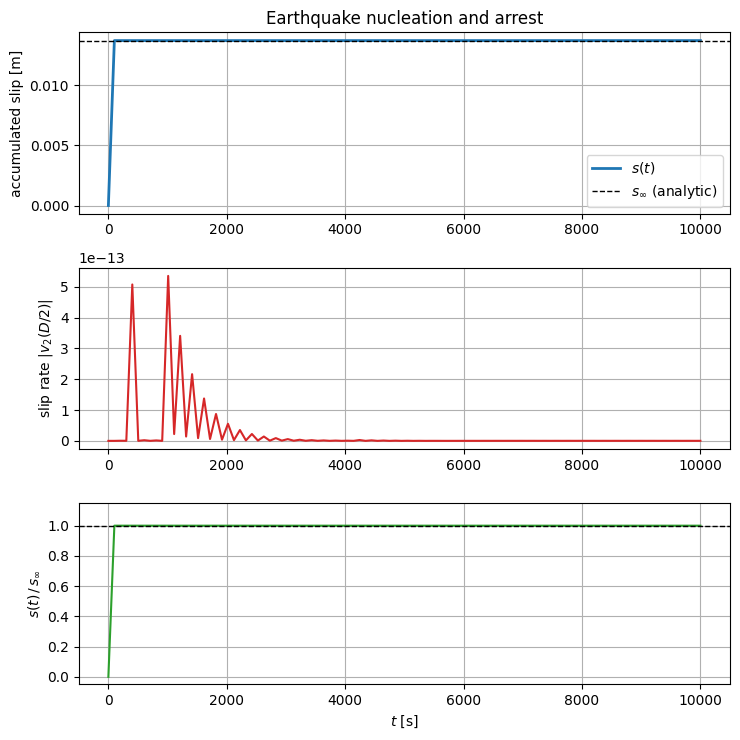

In [175]:
slip_m = slip_hist * L
slip_rate = np.abs(v2_right)

fig, axes = plt.subplots(3, 1, figsize=(7.5, 7.5), sharex=False)

# Panel 1 — slip vs time with analytical asymptote
ax = axes[0]
ax.plot(ts, slip_m, color='C0', lw=2, label=r"$s(t)$")
if EQslip:
    ax.axhline(expd_slip * L, color='k', ls='--', lw=1,
               label=r"$s_\infty$ (analytic)")
ax.set_ylabel("accumulated slip [m]")
ax.set_title("Earthquake nucleation and arrest")
ax.grid(True)
ax.legend(loc='lower right')

# Panel 2 — slip rate
ax = axes[1]
ax.plot(ts, slip_rate, color='C3', lw=1.5)
ax.set_ylabel(r"slip rate $|v_2(D/2)|$")
ax.grid(True)

# Panel 3 — normalised slip fraction
ax = axes[2]
if EQslip and abs(expd_slip) > 0:
    frac = slip_hist / expd_slip
    ax.plot(ts, frac, color='C2', lw=1.5)
    ax.axhline(1.0, color='k', ls='--', lw=1)
    ax.set_ylabel(r"$s(t)\,/\,s_\infty$")
    ax.set_ylim(-0.05, 1.15)
else:
    ax.plot(ts, slip_m, color='C2', lw=1.5)
    ax.set_ylabel("slip [m]")
ax.set_xlabel(r"$t$ [s]")
ax.grid(True)

plt.tight_layout()
plt.show()


## Boundary displacement and velocity

Compare the tangential $u_2$ and $v_2$ traces at the two boundaries.
The left wall is clamped so both traces stay near zero; the right
wall displaces during the slip event, and the velocity trace reveals
the nucleation transient.


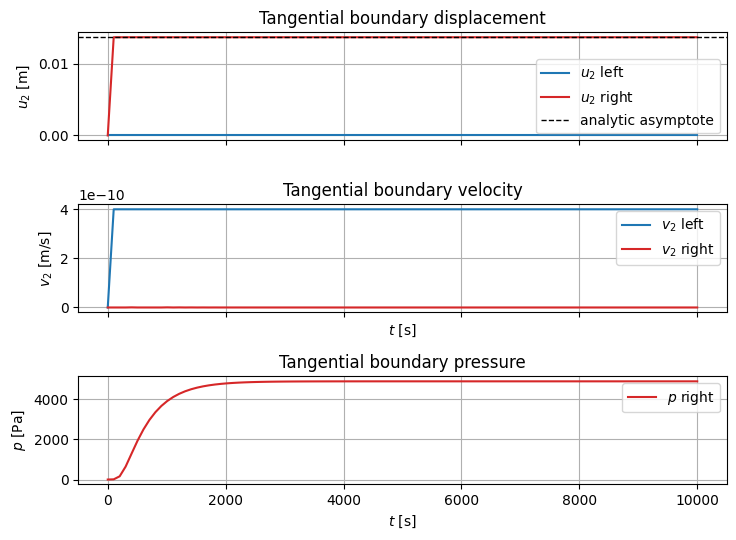

In [176]:
fig, axes = plt.subplots(3, 1, figsize=(7.5, 5.5), sharex=True)

ax = axes[0]
ax.plot(ts, u2_left, label=r"$u_2$ left", color='C0')
ax.plot(ts, u2_right, label=r"$u_2$ right", color='C3')
if EQslip:
    ax.axhline(expd_slip * L, color='k', ls='--', lw=1,
               label=r"analytic asymptote")
ax.set_ylabel(r"$u_2$ [m]")
ax.set_title("Tangential boundary displacement")
ax.grid(True)
ax.legend(loc='lower right')

ax = axes[1]
ax.plot(ts, v2_left, label=r"$v_2$ left", color='C0')
ax.plot(ts, v2_right, label=r"$v_2$ right", color='C3')
ax.set_ylabel(r"$v_2$ [m/s]")
ax.set_xlabel(r"$t$ [s]")
ax.set_title("Tangential boundary velocity")
ax.grid(True)
ax.legend(loc='upper right')

ax = axes[2]
# ax.plot(ts, v2_left, label=r"$v_2$ left", color='C0')
ax.plot(ts, α * p_right, label=r"$p$ right", color='C3')
ax.set_ylabel(r"$p$ [Pa]")
ax.set_xlabel(r"$t$ [s]")
ax.set_title("Tangential boundary pressure")
ax.grid(True)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()
# fig, axes = plt.subplots(2, 1, figsize=(7.5, 5.5), sharex=True)


## Fault stress versus cone strength

The NCP backend stores the tangential reaction as a deviation from the
prestress cone ray $w_0 = -\sigma_{11}^{\text{eff}}\,\mu(0)\,(1+\varepsilon)$,
so the live traction on the fault is
$\tau(t) = w_0 + \Delta\tau(t)$.

The Coulomb feasibility condition is $|\tau(t)| \le \mu(s(t))\,|\sigma_{11}^{\text{eff}}|$.
During sustained slip the numerical trajectory must *touch* the
instantaneous strength $\mu(s)\,|\sigma_{11}^{\text{eff}}|$, and the
relaxation from $\mu(0)\,|\sigma_{11}^{\text{eff}}|$ to
$\mu_{\text{res}}\,|\sigma_{11}^{\text{eff}}|$ is the earthquake stress
drop. Deviation of $|\tau(t)|$ above the strength curve would signal a
cone-feasibility breach.


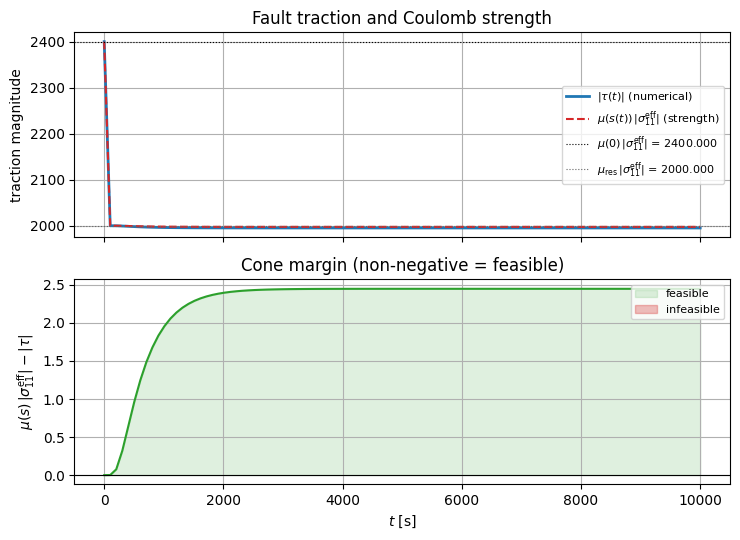

minimum cone margin : +0.000000e+00
stress drop |tau|   : +4.048938e+02


In [177]:
fig, axes = plt.subplots(2, 1, figsize=(7.5, 5.5), sharex=True)

# Panel 1: fault traction vs instantaneous strength ---------------------
ax = axes[0]
ax.plot(ts, tau_wall_abs, color='C0', lw=2, label=r'$|\tau(t)|$ (numerical)')
ax.plot(ts, fault_strength, color='C3', lw=1.5, ls='--',
        label=r'$\mu(s(t))\,|\sigma_{11}^{\mathrm{eff}}|$ (strength)')
ax.axhline(mu_fric(0.0, 0.0) * s11_eff_0, color='k', lw=0.8, ls=':',
           label=rf"$\mu(0)\,|\sigma_{{11}}^{{\mathrm{{eff}}}}|$ = {mu_fric(0.0, 0.0)*s11_eff_0:.3f}")
ax.axhline(mu_res * s11_eff_0, color='0.4', lw=0.8, ls=':',
           label=rf"$\mu_{{\mathrm{{res}}}}\,|\sigma_{{11}}^{{\mathrm{{eff}}}}|$ = {mu_res*s11_eff_0:.3f}")
ax.set_ylabel('traction magnitude')
ax.set_title('Fault traction and Coulomb strength')
ax.grid(True)
ax.legend(loc='center right', fontsize=8)

# Panel 2: cone margin (strength - |tau|) -------------------------------
ax = axes[1]
margin = fault_strength - tau_wall_abs
ax.plot(ts, margin, color='C2', lw=1.5)
ax.axhline(0.0, color='k', lw=0.8)
ax.fill_between(ts, margin, 0.0, where=(margin >= 0), alpha=0.15, color='C2', label='feasible')
ax.fill_between(ts, margin, 0.0, where=(margin < 0), alpha=0.3, color='C3', label='infeasible')
ax.set_ylabel(r'$\mu(s)\,|\sigma_{11}^{\mathrm{eff}}| - |\tau|$')
ax.set_xlabel(r'$t$ [s]')
ax.set_title('Cone margin (non-negative = feasible)')
ax.grid(True)
ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

print(f'minimum cone margin : {float(margin.min()):+.6e}')
print(f'stress drop |tau|   : {float(tau_wall_abs[0] - tau_wall_abs[-1]):+.6e}')


## Step size and Newton work per step

Even with the adaptive controller disabled, the Radau coupled-Newton
path records the step size history and the `info` dict exposes the
per-step Newton iteration count. Together they show where the solver
has to work hardest — typically the slip nucleation transient.


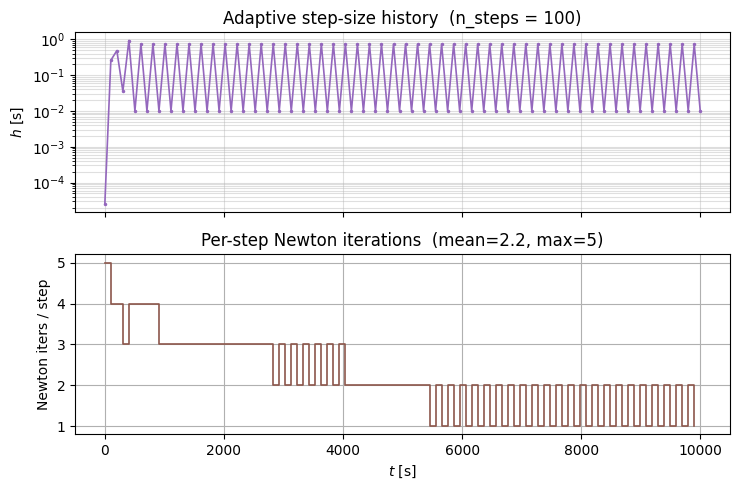

In [178]:
h_hist = np.asarray(h_ncp_hist, dtype=float) if h_ncp_hist is not None else np.array([])
n_h = h_hist.size
t_arr = np.asarray(ts, dtype=float)

# Centre of each accepted step is the cleanest x-axis for h_k.
if n_h and t_arr.size >= n_h + 1:
    t_centres = 0.5 * (t_arr[:n_h] + t_arr[1:n_h + 1])
elif n_h:
    t_centres = t_arr[:n_h]
else:
    t_centres = np.array([])

# ODESolver returns info as a list of (residual, converged_flag, newton_iters)
# tuples — one per completed step.
iters = None
if isinstance(info_ncp, (list, tuple)) and len(info_ncp) > 0 and isinstance(info_ncp[0], tuple):
    try:
        iters = np.asarray([step_info[2] for step_info in info_ncp], dtype=float)
    except (IndexError, TypeError):
        iters = None
elif isinstance(info_ncp, dict):
    for key in ('newton_iters', 'nl_iters', 'iters', 'nonlinear_iters'):
        candidate = info_ncp.get(key)
        if candidate is not None:
            iters = np.asarray(candidate, dtype=float)
            break

fig, axes = plt.subplots(2, 1, figsize=(7.5, 5.0), sharex=True)

ax = axes[0]
if n_h:
    ax.semilogy(t_centres, h_hist, color='C4', lw=1.2, marker='.', ms=3)
ax.set_ylabel(r"$h$ [s]")
_title_mode = 'Adaptive' if USE_ADAPTIVE else 'Fixed-step'
ax.set_title(f'{_title_mode} step-size history  (n_steps = {n_h})')
ax.grid(True, which='both', alpha=0.4)

ax = axes[1]
if iters is not None and len(iters):
    n_it = min(len(iters), n_h) if n_h else len(iters)
    t_it = t_centres[:n_it] if n_h else t_arr[1:1 + n_it]
    ax.step(t_it, iters[:n_it], where='post', color='C5', lw=1.2)
    ax.set_ylabel('Newton iters / step')
    ax.set_title(f"Per-step Newton iterations  (mean={float(iters.mean()):.1f}, max={int(iters.max())})")
else:
    ax.text(0.5, 0.5, "Newton iteration counts not exposed in info_ncp",
            transform=ax.transAxes, ha='center', va='center', color='0.4')
    ax.set_ylabel('')
ax.set_xlabel(r"$t$ [s]")
ax.grid(True)

plt.tight_layout()
plt.show()

## Summary

Compare the numerical final slip to the closed-form asymptote
$s_\infty = -\Delta\mu\,\sigma_{11}^{\text{eff}}\,D / G$, report
the wall-clock cost, and flag the reaction feasibility margin.


In [179]:
print("=" * 64)
print("Radau IIA + NCP Coulomb friction — run summary")
print("=" * 64)
print(f"  horizon            : {tmax:.4g} s")
print(f"  mode               : {mode_label}")
print(f"  h0                 : {h0_init:.4g} s   (n_steps_init={n_steps_init})")
print(f"  steps taken        : {n_steps_taken}")
if h_arr.size:
    print(f"  step h range       : [{float(h_arr.min()):.3e}, {float(h_arr.max()):.3e}] s")
    print(f"  median h           : {float(np.median(h_arr)):.3e} s")
print(f"  physics DOFs       : {ndofs}")
print(f"  augmented DOFs     : {n_aug_total}")
print(f"  wall time          : {time_ncp:.2f} s")
print()
print(f"  final slip (num)   : {slip_hist[-1] * L:.6e} m")
if EQslip:
    rel = abs(slip_hist[-1] - expd_slip) / abs(expd_slip)
    print(f"  analytic asymptote : {expd_slip * L:.6e} m")
    print(f"  relative error     : {rel:.3%}")
print()
mu0 = mu_fric(0.0, 0.0)
mu_final = mu_fric(float(slip_hist[-1]), 0.0)
print(f"  mu(0)              : {mu0:.4f}")
print(f"  mu(s_final)        : {mu_final:.4f}")
print(f"  stress drop (|tau|): {float(tau_wall_abs[0] - tau_wall_abs[-1]):+.6e}")
print(f"  min cone margin    : {float((fault_strength - tau_wall_abs).min()):+.6e}")
if isinstance(info_ncp, (list, tuple)) and len(info_ncp) > 0 and isinstance(info_ncp[0], tuple):
    iter_counts = np.array([step_info[2] for step_info in info_ncp], dtype=float)
    print(f"  Newton iters / step: mean={iter_counts.mean():.1f}, max={int(iter_counts.max())}, total={int(iter_counts.sum())}")
print("=" * 64)


Radau IIA + NCP Coulomb friction — run summary
  horizon            : 1e+04 s
  mode               : adaptive
  h0                 : 2.5e-05 s   (n_steps_init=400000000)
  steps taken        : 99
  step h range       : [2.500e-05, 9.333e-01] s
  median h           : 1.487e-01 s
  physics DOFs       : 553
  augmented DOFs     : 556
  wall time          : 7.33 s

  final slip (num)   : 1.369018e-02 m
  analytic asymptote : 1.369048e-02 m
  relative error     : 0.002%

  mu(0)              : 0.6000
  mu(s_final)        : 0.5000
  stress drop (|tau|): +4.048938e+02
  min cone margin    : +0.000000e+00
  Newton iters / step: mean=2.2, max=5, total=218


In [180]:
# Per-time stress/strain tensors and global colour limits for the tensor widgets.
# Mirrors the canonical post-processing block from the 1D poro notebook.
ss_eff, es = compute_stress_strain(zs_ncp)
ss_eff /= L
I = np.eye(dim)
ss = ss_eff - α * zs_split[:, 6, None, None, :] * I[None, :, :, None]
vmin=np.amin(zs_split, axis=(0,2))*1.1
vmax=np.amax(zs_split, axis=(0,2))*1.1
vmin_ss_eff = np.amin(ss_eff, axis=(0, 3)) * 1.1
vmax_ss_eff = np.amax(ss_eff, axis=(0, 3)) * 1.1
vmin_ss     = np.amin(ss,     axis=(0, 3)) * 1.1
vmax_ss     = np.amax(ss,     axis=(0, 3)) * 1.1
vmin_es     = np.amin(es,     axis=(0, 3)) * 1.1
vmax_es     = np.amax(es,     axis=(0, 3)) * 1.1


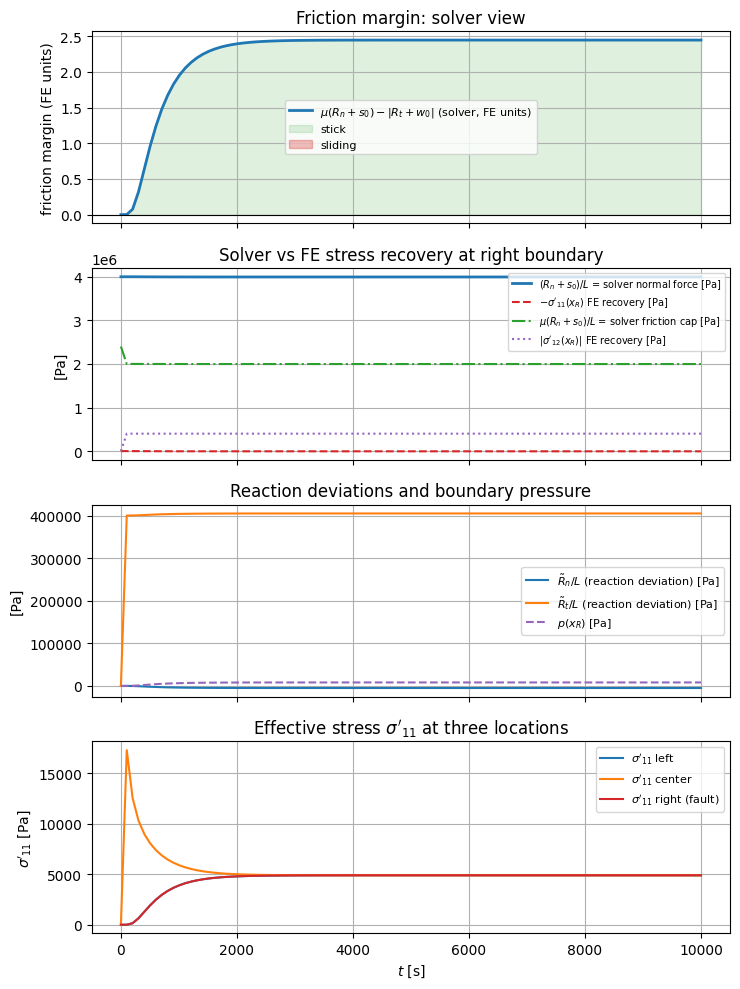

Friction margin range     : [0.0000e+00, 2.4478e+00] (FE units)
R_n + s0 range (Pa)       : [3.9951e+06, 4.0000e+06]
R_n deviation range (Pa)  : [-4.8925e+03, 3.7350e-01]
-sig_eff_11 right (Pa)    : [-4.8925e+03, 3.4669e-01]
sig_eff_11 center (Pa)    : [0.0000e+00, 1.7284e+04]
|sig_12| right (Pa)       : [0.0000e+00, 3.9999e+05]
p(x_R) range (Pa)         : [0.0000e+00, 8.1714e+03]


In [181]:
# Diagnostic: friction margin and effective stress consistency
fig, axes = plt.subplots(4, 1, figsize=(7.5, 10), sharex=True)

Rn_plus_s0 = r_hist[:, 0] + s11_eff_0
sigma_eff_11_right = ss_eff[:, 0, 0, -1]  # Pa (physical)
sigma_12_right = ss_eff[:, 0, 1, -1]       # Pa (physical)

# Panel 1: friction margin = mu*(R_n+s0) - |R_t+w0|  (FE units)
ax = axes[0]
friction_cap = mu_of_s * Rn_plus_s0
tau_abs = np.abs(-s11_eff_0 * mu_fric(0.0, 0.0) * nudge + r_T_delta)
margin = friction_cap - tau_abs
ax.plot(ts, margin, 'C0', lw=2, label=r'$\mu(R_n+s_0) - |R_t+w_0|$ (solver, FE units)')
ax.axhline(0.0, color='k', lw=0.8)
ax.fill_between(ts, margin, 0, where=(margin >= 0), alpha=0.15, color='C2', label='stick')
ax.fill_between(ts, margin, 0, where=(margin < 0), alpha=0.3, color='C3', label='sliding')
ax.set_ylabel('friction margin (FE units)')
ax.set_title('Friction margin: solver view')
ax.grid(True)
ax.legend(fontsize=8)

# Panel 2: solver quantities in physical Pa
ax = axes[1]
ax.plot(ts, Rn_plus_s0 / L, 'C0', lw=2, label=r'$(R_n+s_0)/L$ = solver normal force [Pa]')
ax.plot(ts, -sigma_eff_11_right, 'C3', lw=1.5, ls='--',
        label=r"$-\sigma'_{11}(x_R)$ FE recovery [Pa]")
ax.plot(ts, friction_cap / L, 'C2', lw=1.5, ls='-.',
        label=r'$\mu(R_n+s_0)/L$ = solver friction cap [Pa]')
ax.plot(ts, np.abs(sigma_12_right), 'C4', lw=1.5, ls=':',
        label=r"$|\sigma'_{12}(x_R)|$ FE recovery [Pa]")
ax.set_ylabel('[Pa]')
ax.set_title('Solver vs FE stress recovery at right boundary')
ax.grid(True)
ax.legend(fontsize=7)

# Panel 3: R_n deviation and pressure at boundary
ax = axes[2]
ax.plot(ts, r_hist[:, 0] / L, 'C0', lw=1.5, label=r'$\tilde{R}_n/L$ (reaction deviation) [Pa]')
ax.plot(ts, r_T_delta / L, 'C1', lw=1.5, label=r'$\tilde{R}_t/L$ (reaction deviation) [Pa]')
ax.plot(ts, p_right, 'C4', lw=1.5, ls='--', label=r'$p(x_R)$ [Pa]')
ax.set_ylabel('[Pa]')
ax.set_title('Reaction deviations and boundary pressure')
ax.grid(True)
ax.legend(fontsize=8)

# Panel 4: sigma'_11 at multiple locations
ax = axes[3]
ax.plot(ts, ss_eff[:, 0, 0, 0], 'C0', lw=1.5, label=r"$\sigma'_{11}$ left")
ax.plot(ts, ss_eff[:, 0, 0, len(xcoords)//2], 'C1', lw=1.5, label=r"$\sigma'_{11}$ center")
ax.plot(ts, ss_eff[:, 0, 0, -1], 'C3', lw=1.5, label=r"$\sigma'_{11}$ right (fault)")
ax.set_ylabel(r"$\sigma'_{11}$ [Pa]")
ax.set_xlabel(r'$t$ [s]')
ax.set_title(r"Effective stress $\sigma'_{11}$ at three locations")
ax.grid(True)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'Friction margin range     : [{float(margin.min()):.4e}, {float(margin.max()):.4e}] (FE units)')
print(f'R_n + s0 range (Pa)       : [{float((Rn_plus_s0/L).min()):.4e}, {float((Rn_plus_s0/L).max()):.4e}]')
print(f'R_n deviation range (Pa)  : [{float((r_hist[:,0]/L).min()):.4e}, {float((r_hist[:,0]/L).max()):.4e}]')
print(f'-sig_eff_11 right (Pa)    : [{float((-sigma_eff_11_right).min()):.4e}, {float((-sigma_eff_11_right).max()):.4e}]')
print(f'sig_eff_11 center (Pa)    : [{float(ss_eff[:, 0, 0, len(xcoords)//2].min()):.4e}, {float(ss_eff[:, 0, 0, len(xcoords)//2].max()):.4e}]')
print(f'|sig_12| right (Pa)       : [{float(np.abs(sigma_12_right).min()):.4e}, {float(np.abs(sigma_12_right).max()):.4e}]')
print(f'p(x_R) range (Pa)         : [{float(p_right.min()):.4e}, {float(p_right.max()):.4e}]')


In [182]:
# @widgets.interact(tid=(0, len(ts)-1, 1))
# def show_animate(tid=len(ts)):
#     fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
#     z = zs_split[tid]
#     v1, v2, r1, r2, u1, u2, p = z
#     x = xcoords * L

#     # v2 with per-snapshot autoscale
#     axes[0].plot(x, v2, 'C3', lw=1.5)
#     axes[0].set_ylabel(r"$v_2$ [m/s]")
#     axes[0].set_xlabel("$x$ [m]")
#     axes[0].set_title(f"Tangential velocity  (max={v2.max():.3e})")
#     axes[0].grid(True)

#     # u2 with fixed global limits so the ramp growth is visible
#     axes[1].plot(x, u2, 'C3', lw=1.5)
#     axes[1].set_ylim(vmin[5] * 1.1 if vmin[5] < 0 else -abs(vmax[5]) * 0.02,
#                      vmax[5] * 1.1)
#     axes[1].set_ylabel(r"$u_2$ [m]")
#     axes[1].set_xlabel("$x$ [m]")
#     axes[1].set_title("Tangential displacement")
#     axes[1].grid(True)
#     if EQslip:
#         axes[1].axhline(expd_slip * L, color='k', ls='--', lw=0.8,
#                         label=r"$s_\infty$")
#         axes[1].legend(fontsize=8)

#     # u2 with per-snapshot autoscale (zoom into current range)
#     axes[2].plot(x, u2, 'C3', lw=1.5)
#     axes[2].set_ylabel(r"$u_2$ [m]")
#     axes[2].set_xlabel("$x$ [m]")
#     axes[2].set_title(f"$u_2$ zoomed  (max={u2.max():.3e})")
#     axes[2].grid(True)


#     axes[3].plot(x, u2, 'C3', lw=1.5)
#     axes[3].set_ylabel(r"$u_2$ [m]")
#     axes[3].set_xlabel("$x$ [m]")
#     axes[3].set_title(f"$p$ zoomed  (max={u2.max():.3e})")
#     axes[3].grid(True)
#     fig.suptitle(f"$t = {ts[tid]:.4f}$ s  (step {tid}/{len(ts)-1})", fontsize=11)
#     plt.tight_layout()
#     plt.show()

In [184]:
def plot_solution(z, v_min, v_max):
    v1, v2, r1, r2, u1, u2, p = z
    fig, ax = plt.subplots(2, 2, figsize=(8, 4))
    x = xcoords * L

    ax[0, 0].plot(x, v1, "b", label="$v_1$")
    ax[0, 0].plot(x, v2, "r", label="$v_2$")
    ax[0, 0].legend()
    if min(v_min[0], v_min[1]) != max(v_max[0], v_max[1]):
        ax[0, 0].set_ylim(min(v_min[0], v_min[1]), max(v_max[0], v_max[1]))
    ax[0, 0].set_xlabel("$x$")

    ax[0, 1].plot(x, u1, "b", label="$u_1$")
    ax[0, 1].plot(x, u2, "r", label="$u_2$")
    ax[0, 1].legend()
    if min(v_min[4], v_min[5]) != max(v_max[4], v_max[5]):
        ax[0, 1].set_ylim(min(v_min[4], v_min[5]), max(v_max[4], v_max[5]))
    ax[0, 1].set_xlabel("$x$")

    ax[1, 0].plot(x, r1, "b", label="$r_1$")
    ax[1, 0].plot(x, r2, "r", label="$r_2$")
    ax[1, 0].legend()
    if min(v_min[2], v_min[3]) != max(v_max[2], v_max[3]):
        ax[1, 0].set_ylim(min(v_min[2], v_min[3]), max(v_max[2], v_max[3]))
    ax[1, 0].set_xlabel("$x$")

    ax[1, 1].plot(x, p, "b", label="$p$")
    ax[1, 1].legend()
    if v_min[6] != v_max[6]:
        ax[1, 1].set_ylim(v_min[6], v_max[6])
    ax[1, 1].set_xlabel("$x$")

    plt.tight_layout()

@widgets.interact(tid=(0, len(ts)-1, 1))
def show_all_fields(tid=len(ts)-1):
    plot_solution(zs_split[tid], vmin, vmax)
    print(f"@ t = {ts[tid]:.4f}")

interactive(children=(IntSlider(value=99, description='tid', max=99), Output()), _dom_classes=('widget-interac…

## Stress & strain profiles

Point-wise time histories at left / centre / right, plus interactive spatial sliders
for $\sigma'$, $\sigma$, and $\varepsilon$.

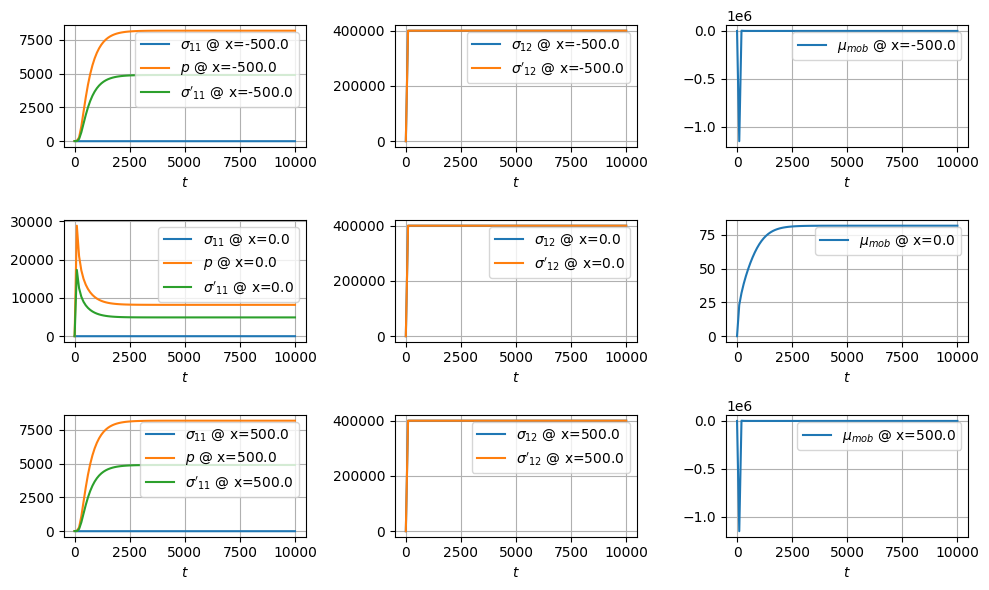

In [185]:
pids = [0, mesh_elements // 2, -1]
plot_point_hist(ss, ss_eff, zs_split, pids)

In [186]:
@widgets.interact(tid=(0, len(ts)-1, 1))
def show_stress(tid=len(ts)):
    plot_tensor(ss_eff[tid], vmin_ss_eff, vmax_ss_eff, name="\\sigma'")
    plot_tensor(ss[tid], vmin_ss, vmax_ss, name="\\sigma")
    plt.show()

interactive(children=(IntSlider(value=99, description='tid', max=99), Output()), _dom_classes=('widget-interac…

In [139]:
@widgets.interact(tid=(0, len(ts)-1, 1))
def show_strain(tid=len(ts)):
    plot_tensor(es[tid], vmin_es, vmax_es, name="\\epsilon")

interactive(children=(IntSlider(value=99, description='tid', max=99), Output()), _dom_classes=('widget-interac…

## Normal contact: gap diagnostic and separation experiments

**Experiment 1** — With the current prestress $\sigma'_{n,0}$ = 4 MPa, verify the
contact stays closed under the injection/extraction source.

**Experiment 2** — Set $\sigma'_{n,0} = 0$, $\mu = 0$ (frictionless Signorini).
The gap should open when the source drives the right boundary away from the wall.

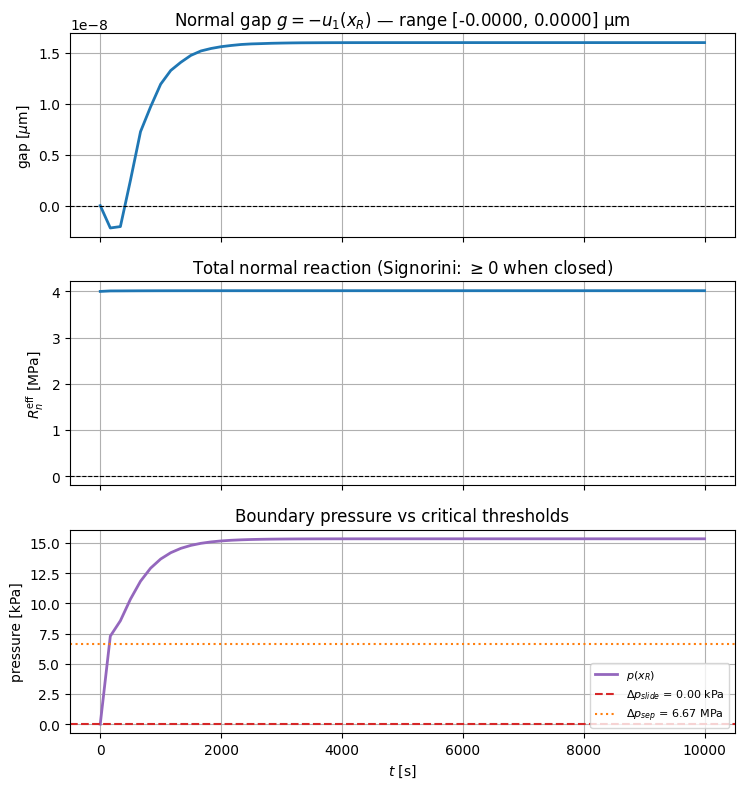

Δp_slide = σ'_n0·(1-nudge)/α = 0.0 Pa = 0.000 kPa
Δp_sep   = σ'_n0/α            = 6666666.7 Pa = 6.667 MPa
max |p(x_R)| = 15346.0 Pa
gap range: [-0.000000, 0.000000] μm
R_n_eff range: [4.000000, 4.015458] MPa
Contact OPENED — prestress insufficient


In [37]:
# --- Experiment 1: gap and normal reaction under current prestress -----------
gap_ncp = -y_ncp[:, u1n_idx]
gap_m = gap_ncp * L
Rn_total_FE = r_hist[:, 0] + s11_eff_0
Rn_total_Pa = Rn_total_FE / L

dp_slide_Pa = float(s11_eff_0 * (1 - nudge) / α / L)
dp_sep_Pa   = float(s11_eff_0 / α / L)

fig, axes = plt.subplots(3, 1, figsize=(7.5, 8), sharex=True)

ax = axes[0]
ax.plot(ts, gap_m * 1e6, 'C0', lw=2)
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_ylabel(r'gap [$\mu$m]')
ax.set_title(f'Normal gap $g = -u_1(x_R)$ — range [{gap_m.min()*1e6:.4f}, {gap_m.max()*1e6:.4f}] \u03bcm')
ax.grid(True)

ax = axes[1]
ax.plot(ts, Rn_total_Pa * 1e-6, 'C0', lw=2)
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_ylabel(r"$R_n^{\mathrm{eff}}$ [MPa]")
ax.set_title(r'Total normal reaction (Signorini: $\geq 0$ when closed)')
ax.grid(True)

ax = axes[2]
ax.plot(ts, p_right * 1e-3, 'C4', lw=2, label=r'$p(x_R)$')
ax.axhline(dp_slide_Pa * 1e-3, color='C3', ls='--', lw=1.5,
           label=rf'$\Delta p_{{slide}}$ = {dp_slide_Pa*1e-3:.2f} kPa')
ax.axhline(dp_sep_Pa * 1e-6, color='C1', ls=':', lw=1.5,
           label=rf'$\Delta p_{{sep}}$ = {dp_sep_Pa*1e-6:.2f} MPa')
ax.set_ylabel('pressure [kPa]')
ax.set_xlabel(r'$t$ [s]')
ax.set_title('Boundary pressure vs critical thresholds')
ax.grid(True)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"\u0394p_slide = \u03c3'_n0\u00b7(1-nudge)/\u03b1 = {dp_slide_Pa:.1f} Pa = {dp_slide_Pa*1e-3:.3f} kPa")
print(f"\u0394p_sep   = \u03c3'_n0/\u03b1            = {dp_sep_Pa:.1f} Pa = {dp_sep_Pa*1e-6:.3f} MPa")
print(f"max |p(x_R)| = {np.max(np.abs(p_right)):.1f} Pa")
print(f"gap range: [{gap_m.min()*1e6:.6f}, {gap_m.max()*1e6:.6f}] \u03bcm")
print(f"R_n_eff range: [{Rn_total_Pa.min()*1e-6:.6f}, {Rn_total_Pa.max()*1e-6:.6f}] MPa")
contact_closed = gap_m.max() <= 1e-15
print(f"Contact {'remains closed' if contact_closed else 'OPENED'} "
      f"\u2014 prestress {'holds' if contact_closed else 'insufficient'}")

## Macklin velocity-level BE + Schur

Same porodynamics problem solved with the Macklin (2019) velocity-level
contact formulation and `BackwardEulerSchur`.  The block system uses
`reaction_units='force'` so the pre-stress offset enters the NCP
evaluation directly (no h-conversion), and `normal_r='auto'` selects
the Delassus preconditioner scaled for velocity-level gaps.

In [38]:
# # Diagnostic: check initial block assembly
# n_p_m = bs_macklin.n_phys
# n_r_m = bs_macklin.n_react
# y_test = np.zeros(n_p_m + n_r_m)
# y_test[:n_p_m] = y0

# blocks = bs_macklin.assemble_blocks(y_test, t=h0_init, h=h0_init, y_prev=y_test)

# import scipy.sparse as _sp
# H = blocks['H']
# print(f'H sparse: {_sp.issparse(H)}, shape: {H.shape}')
# if _sp.issparse(H):
#     print(f'  H nnz: {H.nnz}, density: {H.nnz / H.shape[0]**2:.4f}')
#     H_diag = np.asarray(H.diagonal()).ravel()
# else:
#     H_diag = np.diag(H)
# print(f'  H diag range: [{H_diag.min():.3e}, {H_diag.max():.3e}]')

# print(f'\n||g|| = {np.linalg.norm(blocks["g"]):.4e}')
# print(f'||h_c|| = {np.linalg.norm(blocks["h_c"]):.4e}')
# print(f'h_c = {blocks["h_c"]}')

# print(f'\nB_top shape: {blocks["B_top"].shape}')
# print(f'B_bot shape: {blocks["B_bot"].shape}')
# print(f'B_top[:, 0] nonzero at: {np.where(np.abs(blocks["B_top"][:, 0]) > 1e-15)[0]}')
# print(f'B_top[:, 1] nonzero at: {np.where(np.abs(blocks["B_top"][:, 1]) > 1e-15)[0]}')
# print(f'B_bot[0, :] nonzero at: {np.where(np.abs(blocks["B_bot"][0, :]) > 1e-15)[0]}')
# print(f'B_bot[1, :] nonzero at: {np.where(np.abs(blocks["B_bot"][1, :]) > 1e-15)[0]}')

# print(f'\nC = {blocks["C"]}')
# print(f'precond_diag = {blocks["precond_diag"]}')

# # Auto-r values
# print(f'\nauto_normal_r_base = {bs_macklin._auto_normal_r_base}')
# print(f'auto_friction_r_base = {bs_macklin._auto_friction_r_base}')
# print(f'reaction_units = {bs_macklin._reaction_units}')

# # Offset
# offset = bs_macklin._assemble_offset(y_test)
# print(f'\npre-stress offset = {offset}')

# # Schur complement
# from scipy.sparse.linalg import splu as _splu
# H_lu = _splu(H.tocsc()) if _sp.issparse(H) else None
# H_inv = (lambda v: H_lu.solve(v)) if H_lu else (lambda v: np.linalg.solve(H, v))

# Bt = blocks['B_top']
# Bb = blocks['B_bot']
# C = blocks['C']
# g = blocks['g']
# h_c = blocks['h_c']

# S = C - Bb @ np.column_stack([H_inv(Bt[:, j]) for j in range(n_r_m)])
# print(f'\nSchur complement S (2x2):')
# print(S)
# print(f'S eigenvalues: {np.linalg.eigvalsh(0.5*(S + S.T))}')

# # Solve one step
# schur_rhs = h_c - Bb @ H_inv(g)
# print(f'\nschur_rhs = {schur_rhs}')
# delta_r = np.linalg.solve(S, schur_rhs)
# delta_z = H_inv(g - Bt @ delta_r)
# print(f'||delta_z|| = {np.linalg.norm(delta_z):.4e}')
# print(f'delta_r = {delta_r}')
# print(f'delta_z at contact DOFs: vN={delta_z[vtn_idx]:.4e}, vT={delta_z[vtt_idx]:.4e}')

In [39]:
# import importlib, solve_nivp.macklin_contact
# importlib.reload(solve_nivp.macklin_contact)
# from solve_nivp.macklin_contact import build_macklin_contact_blocked, macklin_be_step

# def gap_func_macklin(y_phys, t):
#     return np.asarray(y_phys[u1n_idx]).ravel() * -1.0

# bs_macklin = build_macklin_contact_blocked(
#     A=E_D,
#     rhs_smooth=rhs_plant,
#     y0=y0,
#     contacts=contact_blocks,
#     gap_func=gap_func_macklin,
#     B=contact_B,
#     D_extract=contact_vel_C,
#     rhs_jac=rhs_jac_aug,
#     ncp_type='fischer_burmeister',
#     normal_r='auto',
#     friction_r='auto',
#     get_s0=contact_s0_force_vec,
#     get_w0=contact_w0_force_vec,
#     reaction_units='force',
# )

# n_p_m = bs_macklin.n_phys
# n_r_m = bs_macklin.n_react
# y_cur_m = np.zeros(n_p_m + n_r_m)
# y_cur_m[:n_p_m] = y0

# h_be = h0_init
# n_steps_be = int(round(tmax / h_be))
# t_m = 0.0

# t_macklin = [t_m]
# y_macklin = [y_cur_m.copy()]
# iters_macklin = []

# print(f'Macklin BE + MUMPS direct: h={h_be:.4g}, n_steps={n_steps_be}, tmax={tmax}')
# print(f'n_phys={n_p_m}, n_react={n_r_m}')

# import time as _time
# _t0 = _time.time()

# for step_i in range(n_steps_be):
#     y_new, err, ok, n_iter = macklin_be_step(
#         bs_macklin, t_m + h_be, y_cur_m, h_be,
#         maxiter=50, tol=1e-8, linear_solver='mumps',
#     )
#     if not ok:
#         print(f'  Step {step_i} FAILED at t={t_m:.4f}, err={err:.2e}, iters={n_iter}')
#         break
#     t_m += h_be
#     y_cur_m = y_new
#     t_macklin.append(t_m)
#     y_macklin.append(y_cur_m.copy())
#     iters_macklin.append(n_iter)
#     if step_i % 20 == 0:
#         print(f'  step {step_i:4d}  t={t_m:.4f}  err={err:.2e}  iters={n_iter}')

# elapsed_m = _time.time() - _t0
# t_macklin = np.array(t_macklin)
# y_macklin = np.array(y_macklin)
# iters_macklin = np.array(iters_macklin)

# print(f'\nMacklin BE + MUMPS elapsed: {elapsed_m:.2f}s')
# print(f'  steps: {len(t_macklin)-1}')
# print(f'  reached t = {t_macklin[-1]:.6g}')
# if len(iters_macklin):
#     print(f'  mean iters: {iters_macklin.mean():.1f}, max: {iters_macklin.max()}')


In [40]:
# # Compare Macklin BE vs NCP Radau at right-boundary DOFs
# fig, axes = plt.subplots(3, 1, figsize=(8, 7), sharex=True)

# # Tangential velocity (slip rate)
# axes[0].plot(t_ncp, y_ncp[:, vtt_idx] * L, label='NCP+Radau')
# axes[0].plot(t_macklin, y_macklin[:, vtt_idx] * L, '--', label='Macklin+BE')
# axes[0].set_ylabel(r'$v_2$ [m/s]')
# axes[0].legend()
# axes[0].grid(True)

# # Tangential displacement (slip)
# axes[1].plot(t_ncp, y_ncp[:, u2t_idx] * L, label='NCP+Radau')
# axes[1].plot(t_macklin, y_macklin[:, u2t_idx] * L, '--', label='Macklin+BE')
# axes[1].set_ylabel(r'$u_2$ [m]')
# axes[1].legend()
# axes[1].grid(True)

# # Accumulated slip
# axes[2].plot(t_ncp, y_ncp[:, slip_idx] * L, label='NCP+Radau')
# axes[2].plot(t_macklin, y_macklin[:, slip_idx] * L, '--', label='Macklin+BE')
# axes[2].set_ylabel('Slip [m]')
# axes[2].set_xlabel(r'$t$ [s]')
# axes[2].legend()
# axes[2].grid(True)

# fig.suptitle('NCP+Radau vs Macklin+BE: right-boundary histories')
# plt.tight_layout()
# plt.show()

# # Reaction comparison
# r_ncp = y_ncp[:, ndofs_aug:]
# r_macklin = y_macklin[:, n_p_m:]

# fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
# axes[0].plot(t_ncp, r_ncp[:, 0], label='NCP+Radau')
# axes[0].plot(t_macklin, r_macklin[:, 0], '--', label='Macklin+BE')
# axes[0].set_ylabel(r'$r_N$')
# axes[0].legend()
# axes[0].grid(True)

# axes[1].plot(t_ncp, r_ncp[:, 1], label='NCP+Radau')
# axes[1].plot(t_macklin, r_macklin[:, 1], '--', label='Macklin+BE')
# axes[1].set_ylabel(r'$r_T$')
# axes[1].set_xlabel(r'$t$ [s]')
# axes[1].legend()
# axes[1].grid(True)

# fig.suptitle('Reaction histories: NCP+Radau vs Macklin+BE')
# plt.tight_layout()
# plt.show()